# 📊 Global Food Security & Climate Resilience
### Analytical Exploration & Business Insights

---

## 📖 Project Overview

This notebook explores the integrated dataset through **12 analytical questions** to examine the relationships between food security, climate change, economic development, agricultural resources, and food import dependency across **177 countries** from **2010 to 2023**.

Each analysis combines statistical evidence with carefully designed Plotly visualizations to communicate insights clearly and support informed decision-making.

---

## 🎯 Analysis Objectives

This notebook aims to:

- Identify global trends and country-level patterns
- Compare food security across economic and environmental indicators
- Examine relationships between climate change and food availability
- Evaluate national resilience using multiple development indicators
- Present findings through clear, publication-ready visualizations

---

> **Outcome:** Evidence-based insights into the key factors influencing global food security and climate resilience, presented through interactive visual analytics.

# Analytical Questions Overview

**Q1.** Does higher GDP per capita consistently translate into better food availability?

Goal: Determine whether countries with higher GDP per capita consistently show higher daily calorie availability, or whether income alone is insufficient to explain the pattern.

---

**Q2.** How strongly is temperature change associated with food availability across countries?

Goal: Assess whether countries with larger annual temperature increases tend to have lower daily calorie availability.

---

**Q3.** Which factor shows a stronger relationship with food availability — economic prosperity or climate stress?

Goal: Compare the correlation strength of GDP per capita and temperature change against daily calorie availability, to identify the dominant predictor.

---

**Q4.** Which countries demonstrate the highest climate resilience while maintaining food security?

Goal: Identify countries that combine above-average temperature change with above-average daily calorie availability, using a quadrant analysis.

---

**Q5.** Which food groups contribute the most to global calorie availability?

Goal: Rank food groups by their cumulative contribution to global calorie availability between 2010 and 2023.

---

**Q6.** Does greater dependence on food imports improve national food availability?

Goal: Determine whether higher import dependency is associated with better food availability, after controlling for what GDP per capita alone would predict.

---

**Q7.** Does higher domestic food production lead to greater national food availability?

Goal: Examine whether countries with higher per-capita domestic production also achieve higher daily calorie availability.

---

**Q8.** Does more agricultural land automatically improve food security?

Goal: Compare median daily calorie availability across agricultural-land categories to test whether land share alone predicts food security.

---

**Q9.** Has economic growth kept pace with improvements in food availability since 2010?

Goal: Compare the trajectory of average GDP per capita against average daily calorie availability, indexed to a common baseline, to see if the two growth rates track together.

---

**Q10.** Which countries achieved the greatest improvement in food availability since 2010?

Goal: Identify the countries with the largest increase in daily calorie availability between 2010 and 2023.

---

**Q11.** How have global food supply and climate patterns evolved from 2010 to 2023?

Goal: Track global average food availability alongside global average temperature change over the study period, indexed to a common baseline.

---

**Q12.** Which countries represent the best and worst overall balance of climate resilience and food security?

Goal: Build a composite resilience index from food availability, GDP per capita, temperature change, and import dependency, and rank countries by overall performance.

# Phase 1 — Import Libraries & Project Setup

In [1]:
# ==========================================================
# Data Visualization Final Project
# Notebook 2 : Analytical Questions
# Phase 1 - Project Setup
# ==========================================================

import pandas as pd
import numpy as np

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# ----------------------------------------------------------
# Project Paths
# ----------------------------------------------------------

PROJECT_DIR = Path.cwd()

PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"

OUTPUT_DIR = PROJECT_DIR / "outputs"

TABLES_DIR = OUTPUT_DIR / "analysis_tables"

TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Notebook 2 initialized successfully.")

Notebook 2 initialized successfully.


# Phase 1b — Design System (CVD-safe palette)

In [19]:
# ==========================================================
# Design tokens — per brief: grey for context, ONE highlight colour
# ==========================================================

CONTEXT_GREY = "#B0B0B0"   # de-emphasized / baseline data
BASE_BLUE    = "#2A6F97"   # primary series colour
HIGHLIGHT    = "#E07A2C"   # the ONE accent — used only to draw the eye to the finding
HIGHLIGHT_ALT = "#0072B2"  # Okabe-Ito blue — second CVD-safe accent, used only where
                            # a chart sits visually close to another HIGHLIGHT chart
COLOR_NAVY   = "#183153"   # titles
COLOR_SUB    = "#6B7280"   # subtitles
COLOR_GRID   = "#E5E7EB"
BG           = "#F8FAFC"

print("Design tokens loaded.")


Design tokens loaded.


# Phase 2 — Load Master Dataset

In [20]:
# ==========================================================
# Phase 2 - Load Master Dataset
# ==========================================================

master_df = pd.read_csv(
    PROCESSED_DATA_DIR / "Food_Security_Master_Dataset.csv"
)

print(master_df.shape)

master_df.head()

(270961, 14)


,Country,Year,Item,Calories_per_Capita,Food_kg_per_Capita,Domestic_Supply,Production,Imports,Exports,Temperature_Change,GDP_per_Capita,Population,Agricultural_Land_Percent,Region
0,Afghanistan,2010,"Alcohol, Non-Food",NaN,NaN,0.0,0.0,NaN,NaN,1.658,560.621505,28284089.0,58.1344,Asia
1,Afghanistan,2010,Alcoholic Beverages,0.15,0.11,3.0,0.0,3.0,NaN,1.658,560.621505,28284089.0,58.1344,Asia
2,Afghanistan,2010,Animal Products,199.39,NaN,NaN,NaN,NaN,NaN,1.658,560.621505,28284089.0,58.1344,Asia
3,Afghanistan,2010,Animal fats,32.41,1.66,48.0,44.0,3.0,NaN,1.658,560.621505,28284089.0,58.1344,Asia
4,Afghanistan,2010,Apples and products,4.22,2.92,87.0,60.0,10.0,1.0,1.658,560.621505,28284089.0,58.1344,Asia


# Phase 3 — Dataset Overview

In [21]:
# ==========================================================
# Phase 3 - Dataset Overview
# ==========================================================

print("="*70)
print("MASTER DATASET OVERVIEW")
print("="*70)

print()

print("Rows      :", len(master_df))
print("Columns   :", len(master_df.columns))

print("Countries :", master_df["Country"].nunique())
print("Years     :", master_df["Year"].min(),
      "-",
      master_df["Year"].max())

print("Items      :", master_df["Item"].nunique())

print()

display(master_df.head())

print()

master_df.info()

MASTER DATASET OVERVIEW

Rows      : 270961
Columns   : 14
Countries : 177
Years     : 2010 - 2023
Items      : 119



,Country,Year,Item,Calories_per_Capita,Food_kg_per_Capita,Domestic_Supply,Production,Imports,Exports,Temperature_Change,GDP_per_Capita,Population,Agricultural_Land_Percent,Region
0,Afghanistan,2010,"Alcohol, Non-Food",NaN,NaN,0.0,0.0,NaN,NaN,1.658,560.621505,28284089.0,58.1344,Asia
1,Afghanistan,2010,Alcoholic Beverages,0.15,0.11,3.0,0.0,3.0,NaN,1.658,560.621505,28284089.0,58.1344,Asia
2,Afghanistan,2010,Animal Products,199.39,NaN,NaN,NaN,NaN,NaN,1.658,560.621505,28284089.0,58.1344,Asia
3,Afghanistan,2010,Animal fats,32.41,1.66,48.0,44.0,3.0,NaN,1.658,560.621505,28284089.0,58.1344,Asia
4,Afghanistan,2010,Apples and products,4.22,2.92,87.0,60.0,10.0,1.0,1.658,560.621505,28284089.0,58.1344,Asia



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270961 entries, 0 to 270960
Data columns (total 14 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Country                    270961 non-null  object 
 1   Year                       270961 non-null  int64  
 2   Item                       270961 non-null  object 
 3   Calories_per_Capita        245713 non-null  float64
 4   Food_kg_per_Capita         243709 non-null  float64
 5   Domestic_Supply            263770 non-null  float64
 6   Production                 169721 non-null  float64
 7   Imports                    253493 non-null  float64
 8   Exports                    205926 non-null  float64
 9   Temperature_Change         265082 non-null  float64
 10  GDP_per_Capita             269486 non-null  float64
 11  Population                 270485 non-null  float64
 12  Agricultural_Land_Percent  269402 non-null  float64
 13  Region                     2

# Phase 4 — Select Required Variables

In [22]:
# ==========================================================
# Phase 4 - Analysis Dataset
# ==========================================================

analysis_df = master_df[
    [
        "Country",
        "Year",
        "Item",

        "Calories_per_Capita",
        "Food_kg_per_Capita",

        "Domestic_Supply",
        "Production",
        "Imports",
        "Exports",

        "Temperature_Change",
        "GDP_per_Capita",
        "Population",
        "Agricultural_Land_Percent"
    ]
].copy()

print(analysis_df.shape)

analysis_df.head()

(270961, 13)


,Country,Year,Item,Calories_per_Capita,Food_kg_per_Capita,Domestic_Supply,Production,Imports,Exports,Temperature_Change,GDP_per_Capita,Population,Agricultural_Land_Percent
0,Afghanistan,2010,"Alcohol, Non-Food",NaN,NaN,0.0,0.0,NaN,NaN,1.658,560.621505,28284089.0,58.1344
1,Afghanistan,2010,Alcoholic Beverages,0.15,0.11,3.0,0.0,3.0,NaN,1.658,560.621505,28284089.0,58.1344
2,Afghanistan,2010,Animal Products,199.39,NaN,NaN,NaN,NaN,NaN,1.658,560.621505,28284089.0,58.1344
3,Afghanistan,2010,Animal fats,32.41,1.66,48.0,44.0,3.0,NaN,1.658,560.621505,28284089.0,58.1344
4,Afghanistan,2010,Apples and products,4.22,2.92,87.0,60.0,10.0,1.0,1.658,560.621505,28284089.0,58.1344


# Phase 5 — Data Quality Check

In [23]:
# ==========================================================
# Phase 5 - Analysis Dataset Validation
# ==========================================================

print("="*70)
print("Missing Values")
print("="*70)

missing = (
    analysis_df
    .isna()
    .sum()
    .to_frame("Missing")
)

missing["Percent"] = (
    missing["Missing"] /
    len(analysis_df) *
    100
).round(2)

display(missing.sort_values("Missing", ascending=False))

Missing Values


,Missing,Percent
Production,101240,37.36
Exports,65035,24.00
Food_kg_per_Capita,27252,10.06
Calories_per_Capita,25248,9.32
Imports,17468,6.45
Domestic_Supply,7191,2.65
Temperature_Change,5879,2.17
Agricultural_Land_Percent,1559,0.58
GDP_per_Capita,1475,0.54
Population,476,0.18


# Phase 6 — Duplicate Validation

In [24]:
# ==========================================================
# Phase 6 - Duplicate Validation
# ==========================================================

duplicates = analysis_df.duplicated(
    ["Country", "Year", "Item"]
).sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


# Phase 7 — Descriptive Statistics

In [25]:
# ==========================================================
# Phase 7 - Numerical Summary
# ==========================================================

display(
    analysis_df.describe().round(2)
)

,Year,Calories_per_Capita,Food_kg_per_Capita,Domestic_Supply,Production,Imports,Exports,Temperature_Change,GDP_per_Capita,Population,Agricultural_Land_Percent
count,270961.00,245713.00,243709.00,263770.00,169721.00,253493.00,205926.00,265082.00,269486.00,2.704850e+05,269402.00
mean,2016.57,111.46,13.92,1129.15,1747.57,178.16,202.76,1.27,14945.51,4.354544e+07,38.77
std,4.03,397.82,34.76,13542.51,17251.08,1393.50,1870.26,0.57,20369.77,1.549431e+08,21.59
min,2010.00,0.00,0.00,-1886.00,0.00,0.00,-62.00,-0.48,330.62,9.816000e+03,0.45
25%,2013.00,0.57,0.08,0.00,2.00,0.00,0.00,0.87,2271.20,2.399632e+06,20.63
50%,2017.00,7.07,1.29,11.00,30.00,3.00,1.00,1.20,6140.87,9.412380e+06,39.92
75%,2020.00,42.82,9.07,131.00,293.00,33.00,19.00,1.60,18666.37,3.076572e+07,54.05
max,2023.00,3966.57,594.54,782585.00,782586.00,114396.00,110250.00,3.70,134965.82,1.438070e+09,86.48


# Phase 8 — Save Clean Analysis Dataset

In [26]:
# ==========================================================
# Phase 8 - Save Analysis Dataset
# ==========================================================

analysis_df.to_csv(
    TABLES_DIR / "Analysis_Dataset.csv",
    index=False
)

print("Analysis dataset saved successfully.")

Analysis dataset saved successfully.


# Phase 10 — Executive KPI Dashboard

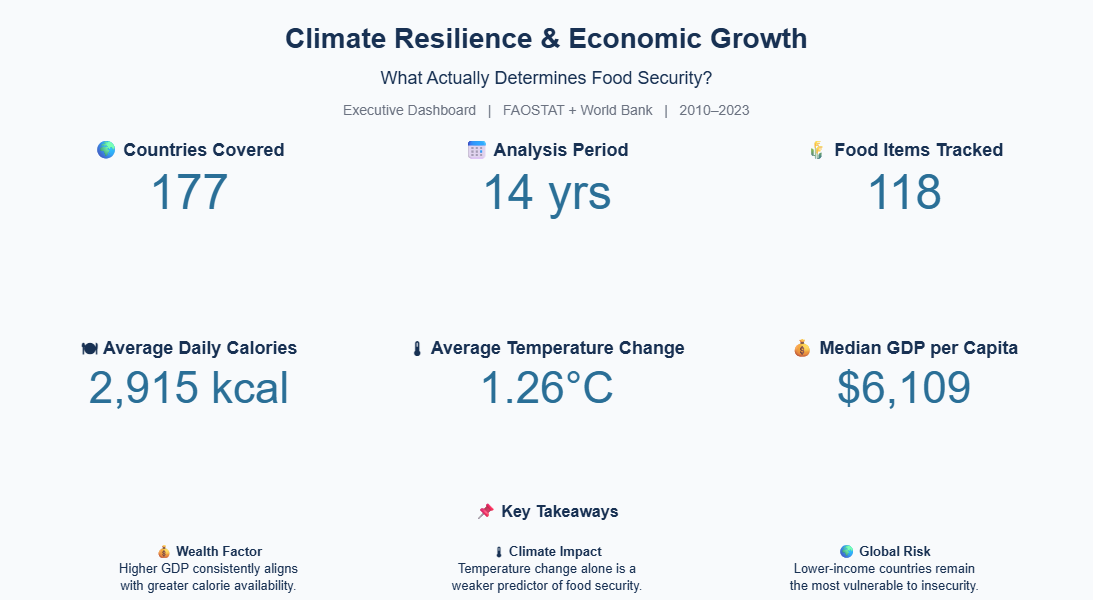

In [27]:
# ==========================================================
# Phase 10
# Executive Dashboard
# ==========================================================

import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ----------------------------------------------------------
# DATA
# ----------------------------------------------------------

country_year_totals = (
    analysis_df
    .query("Item == 'Grand Total'")
    .reset_index(drop=True)
)

countries = country_year_totals["Country"].nunique()
years = country_year_totals["Year"].nunique()

food_items = (
    analysis_df
    .query("Item != 'Grand Total'")
    ["Item"]
    .nunique()
)

avg_calories = country_year_totals["Calories_per_Capita"].mean()
avg_temp = country_year_totals["Temperature_Change"].mean()
median_gdp = country_year_totals["GDP_per_Capita"].median()

# ----------------------------------------------------------
# COLORS
# ----------------------------------------------------------

# Aligned to the shared Phase 1b design tokens so the KPI
# dashboard uses the exact same colours as every AQ chart below.
NAVY = COLOR_NAVY
BLUE = BASE_BLUE
GREY = COLOR_SUB
BACKGROUND = BG

# ----------------------------------------------------------
# DASHBOARD LAYOUT
# ----------------------------------------------------------

fig = make_subplots(
    rows=2,
    cols=3,
    specs=[
        [{"type":"indicator"}, {"type":"indicator"}, {"type":"indicator"}],
        [{"type":"indicator"}, {"type":"indicator"}, {"type":"indicator"}]
    ],
    vertical_spacing=0.15, 
    horizontal_spacing=0.08
)

# ==========================================================
# TOP ROW KPIs
# ==========================================================

TITLE_FONT = dict(size=18, color=NAVY)
VALUE_FONT = dict(size=48, color=BLUE)

# ----------------------------------------------------------
# Countries
# ----------------------------------------------------------
fig.add_trace(
    go.Indicator(
        mode="number",
        value=countries,
        number=dict(font=VALUE_FONT),
        title=dict(text="<b>🌍 Countries Covered</b>", font=TITLE_FONT)
    ),
    row=1, col=1
)

# ----------------------------------------------------------
# Analysis Period
# ----------------------------------------------------------
fig.add_trace(
    go.Indicator(
        mode="number",
        value=years,
        number=dict(suffix=" yrs", font=VALUE_FONT),
        title=dict(text="<b>📅 Analysis Period</b>", font=TITLE_FONT)
    ),
    row=1, col=2
)

# ----------------------------------------------------------
# Food Items
# ----------------------------------------------------------
fig.add_trace(
    go.Indicator(
        mode="number",
        value=food_items,
        number=dict(font=VALUE_FONT),
        title=dict(text="<b>🌾 Food Items Tracked</b>", font=TITLE_FONT)
    ),
    row=1, col=3
)

# ==========================================================
# SECOND ROW KPIs
# ==========================================================

# ----------------------------------------------------------
# Average Calories
# ----------------------------------------------------------
fig.add_trace(
    go.Indicator(
        mode="number",
        value=avg_calories,
        number=dict(
            valueformat=",.0f",
            suffix=" kcal",
            font=dict(size=44, color=BLUE)
        ),
        title=dict(text="<b>🍽 Average Daily Calories</b>", font=TITLE_FONT)
    ),
    row=2, col=1
)

# ----------------------------------------------------------
# Average Temperature
# ----------------------------------------------------------
fig.add_trace(
    go.Indicator(
        mode="number",
        value=avg_temp,
        number=dict(
            valueformat=".2f",
            suffix="°C",
            font=dict(size=44, color=BLUE)
        ),
        title=dict(text="<b>🌡 Average Temperature Change</b>", font=TITLE_FONT)
    ),
    row=2, col=2
)

# ----------------------------------------------------------
# Median GDP
# ----------------------------------------------------------
fig.add_trace(
    go.Indicator(
        mode="number",
        value=median_gdp,
        number=dict(
            prefix="$",
            valueformat=",.0f",
            font=dict(size=44, color=BLUE)
        ),
        title=dict(text="<b>💰 Median GDP per Capita</b>", font=TITLE_FONT)
    ),
    row=2, col=3
)

# ==========================================================
# EXECUTIVE LAYOUT
# ==========================================================

fig.update_layout(
    template="plotly_white",
    width=1000,      
    height=600,      
    paper_bgcolor=BACKGROUND,
    plot_bgcolor=BACKGROUND,
    margin=dict(
        l=50,
        r=50,
        t=120,       
        b=140        # Keeps bottom margin spacious for text containment
    ),
    font=dict(
        family="Arial",
        color=NAVY
    ),
    title=dict(
        text="<b>Climate Resilience & Economic Growth</b><br>"
             "<span style='font-size:18px;'>What Actually Determines Food Security?</span>",
        x=0.5,
        y=0.92,       
        xanchor="center",
        font=dict(size=28, color=NAVY)
    )
)

# ==========================================================
# SUBTITLE
# ==========================================================

fig.add_annotation(
    x=0.5,
    y=1.06,          
    xref="paper",
    yref="paper",
    showarrow=False,
    text="Executive Dashboard &nbsp;&nbsp;|&nbsp;&nbsp; FAOSTAT + World Bank &nbsp;&nbsp;|&nbsp;&nbsp; 2010–2023",
    font=dict(size=14, color=GREY)
)

# ==========================================================
# KEY TAKEAWAYS
# ==========================================================

fig.add_annotation(
    x=0.5,            # 👈 Centers the main header in the exact middle of the canvas
    y=-0.12,
    xref="paper",
    yref="paper",
    showarrow=False,
    text="<b>📌 Key Takeaways</b>",
    font=dict(size=16, color=NAVY),
    xanchor="center", # 👈 Anchors the main text block from its exact center point
    yanchor="top"
)

# Column 1 (Centered under Left Metrics)
fig.add_annotation(
    x=0.16,           
    y=-0.24,
    xref="paper",
    yref="paper",
    showarrow=False,
    text="<b>💰 Wealth Factor</b><br>Higher GDP consistently aligns<br>with greater calorie availability.",
    font=dict(size=13, color=NAVY),
    align="center",   
    xanchor="center", 
    yanchor="top"
)

# Column 2 (Centered under Middle Metrics)
fig.add_annotation(
    x=0.50,           
    y=-0.24,
    xref="paper",
    yref="paper",
    showarrow=False,
    text="<b>🌡 Climate Impact</b><br>Temperature change alone is a<br>weaker predictor of food security.",
    font=dict(size=13, color=NAVY),
    align="center",   
    xanchor="center", 
    yanchor="top"
)

# Column 3 (Centered under Right Metrics)
fig.add_annotation(
    x=0.84,           
    y=-0.24,
    xref="paper",
    yref="paper",
    showarrow=False,
    text="<b>🌍 Global Risk</b><br>Lower-income countries remain<br>the most vulnerable to insecurity.",
    font=dict(size=13, color=NAVY),
    align="center",   
    xanchor="center", 
    yanchor="top"
)

# ==========================================================
# SHOW
# ==========================================================

fig.show(
    config={
        "displayModeBar": False
    }
)


In [28]:
kpi_country_year_df = (
    master_df[master_df["Item"] == "Grand Total"]
    .groupby(["Country","Year"], as_index=False)
    .agg({
        "Calories_per_Capita":"first",
        "Food_kg_per_Capita":"first",
        "GDP_per_Capita":"first",
        "Temperature_Change":"first",
        "Population":"first",
        "Agricultural_Land_Percent":"first",
        "Region":"first",
        "Imports":"first",
        "Exports":"first",
        "Production":"first",
        "Domestic_Supply":"first"
    })
)

kpi_country_year_df.head()
print("Sanity check — avg calories/capita:", kpi_country_year_df["Calories_per_Capita"].mean())
# should print something in the 2,600–3,000 range, not 113

Sanity check — avg calories/capita: 2915.1813308302044


In [29]:
production_totals = (
    master_df[master_df["Item"] != "Grand Total"]
    .groupby(["Country", "Year"], as_index=False)
    .agg({
        "Production": "sum",
        "Imports": "sum",
        "Exports": "sum",
        "Domestic_Supply": "sum",   
    })
    .rename(columns={
        "Production": "Production_Total",
        "Imports": "Imports_Total",
        "Exports": "Exports_Total",
        "Domestic_Supply": "Domestic_Supply_Total",  
    })
)

kpi_country_year_df = kpi_country_year_df.merge(
    production_totals, on=["Country", "Year"], how="left"
)

print("Domestic_Supply_Total nulls:", kpi_country_year_df["Domestic_Supply_Total"].isna().sum())

Domestic_Supply_Total nulls: 0


In [30]:
kpi_country_year_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2397 entries, 0 to 2396
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Country                    2397 non-null   object 
 1   Year                       2397 non-null   int64  
 2   Calories_per_Capita        2397 non-null   float64
 3   Food_kg_per_Capita         0 non-null      float64
 4   GDP_per_Capita             2383 non-null   float64
 5   Temperature_Change         2345 non-null   float64
 6   Population                 2392 non-null   float64
 7   Agricultural_Land_Percent  2383 non-null   float64
 8   Region                     2397 non-null   object 
 9   Imports                    0 non-null      float64
 10  Exports                    0 non-null      float64
 11  Production                 0 non-null      float64
 12  Domestic_Supply            0 non-null      float64
 13  Production_Total           2397 non-null   float

In [31]:
kpi_country_year_df.describe().round(2)

,Year,Calories_per_Capita,Food_kg_per_Capita,GDP_per_Capita,Temperature_Change,Population,Agricultural_Land_Percent,Imports,Exports,Production,Domestic_Supply,Production_Total,Imports_Total,Exports_Total,Domestic_Supply_Total
count,2397.00,2397.00,0.0,2383.00,2345.00,2.392000e+03,2383.00,0.0,0.0,0.0,0.0,2397.00,2397.00,2397.00,2397.00
mean,2016.56,2915.18,NaN,14810.91,1.26,4.230771e+07,38.74,NaN,NaN,NaN,NaN,123737.80,18841.60,17418.88,124254.00
std,4.04,449.35,NaN,20260.91,0.57,1.519407e+08,21.66,NaN,NaN,NaN,NaN,430792.16,43906.11,44784.78,432855.94
min,2010.00,1810.45,NaN,330.62,-0.48,9.816000e+03,0.45,NaN,NaN,NaN,NaN,23.00,8.00,0.00,21.00
25%,2013.00,2596.15,NaN,2224.77,0.87,2.248313e+06,20.45,NaN,NaN,NaN,NaN,3740.00,1629.00,322.00,5724.00
50%,2017.00,2906.57,NaN,6109.29,1.20,9.074534e+06,39.87,NaN,NaN,NaN,NaN,20821.00,5359.00,1966.00,23814.00
75%,2020.00,3269.79,NaN,18434.13,1.60,3.022844e+07,54.08,NaN,NaN,NaN,NaN,62954.00,16522.00,12511.00,68245.00
max,2023.00,3966.57,NaN,134965.82,3.70,1.438070e+09,86.48,NaN,NaN,NaN,NaN,4451796.00,584580.00,451574.00,4930103.00


In [32]:
# ==========================================================
# Phase 12 - Save Analysis Dataset
# ==========================================================

kpi_country_year_df.to_csv(
    PROCESSED_DATA_DIR / "KPI_Country_Year_Dataset.csv",
    index=False
)

print("KPI country-year dataset saved.")

KPI country-year dataset saved.


In [33]:
print(kpi_country_year_df["Region"].value_counts())
print('\n')
print( kpi_country_year_df.shape)

Region
Asia        612
Africa      602
Europe      546
Americas    472
Oceania     165
Name: count, dtype: int64


(2397, 17)


In [34]:
print("Unique countries in KPI dataset:", kpi_country_year_df["Country"].nunique())

Unique countries in KPI dataset: 177


# Phase 13 — Analytical Questions

---

## Analytical Question 1

### Does higher GDP per capita consistently translate into better food availability?

Economic growth is often assumed to be the primary lever for food security, on the theory that higher national income buys better infrastructure, purchasing power, and agricultural investment. Testing this assumption directly — rather than taking it for granted — is the foundation the rest of this analysis builds on.

**Goal:** Determine whether countries with higher GDP per capita consistently show higher daily calorie availability, or whether income alone is insufficient to explain the pattern.

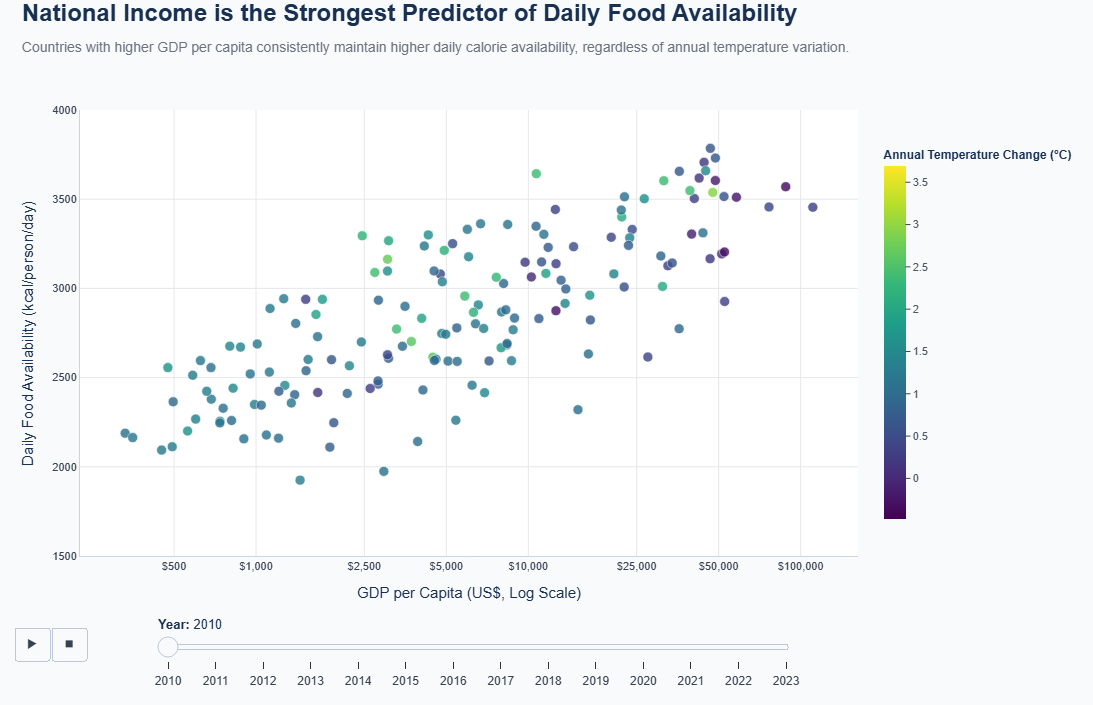

In [35]:
# ==========================================================
# AQ1
# How Strongly Does National Income Influence Daily Food Availability?
# ==========================================================

import plotly.express as px
import numpy as np

# ----------------------------------------------------------
# Data Preparation
# ----------------------------------------------------------

aq1_df = (
    analysis_df
    .query("Item == 'Grand Total'")
    .dropna(
        subset=[
            "GDP_per_Capita",
            "Calories_per_Capita",
            "Temperature_Change"
        ]
    )
    .copy()
)

aq1_df.sort_values("Year", inplace=True)

temp_min = aq1_df["Temperature_Change"].min()
temp_max = aq1_df["Temperature_Change"].max()

fig = px.scatter(
    aq1_df,
    x="GDP_per_Capita",
    y="Calories_per_Capita",
    color="Temperature_Change",
    hover_name="Country",
    animation_frame="Year",
    log_x=True,
    range_color=[temp_min, temp_max],
    color_continuous_scale="Viridis",
    labels={
        "GDP_per_Capita":
        "GDP per Capita (US$, Log Scale)",
        "Calories_per_Capita":
        "Daily Food Availability (kcal/person/day)",
        "Temperature_Change":
        "Temperature Change (°C)"
    },

    hover_data={
        "GDP_per_Capita":":$,.0f",
        "Calories_per_Capita":":.0f",
        "Temperature_Change":":.2f"
    }

)

# ----------------------------------------------------------
# Marker Styling
# ----------------------------------------------------------

fig.update_traces(
    marker=dict(
        size=10,
        opacity=0.82,
        line=dict(
            width=0.6,
            color="white"
        )

    ),

    selector=dict(mode="markers")

)

# ----------------------------------------------------------
# Executive Layout
# ----------------------------------------------------------

fig.update_layout(
    template="plotly_white",
    width=1120,
    height=690,
    paper_bgcolor=BG,
    plot_bgcolor="white",
    margin=dict(
        l=80,
        r=70,
        t=110,
        b=80
    ),
    font=dict(
        family="Arial",
        size=12,
        color="#374151"
    ),
    title=dict(
        text=(
            "<b>National Income is the Strongest Predictor of Daily Food Availability</b>"
            "<br>"
            "<span style='font-size:14px;color:#6B7280;'>"
            "Countries with higher GDP per capita consistently maintain higher daily calorie availability, "
            "regardless of annual temperature variation."
            "</span>"
        ),
        x=0.02,
        y=0.97,
        xanchor="left",
        font=dict(
            family="Arial",
            size=24,
            color=COLOR_NAVY
        )
    ),
    xaxis=dict(
        title="GDP per Capita (US$, Log Scale)",
        title_font=dict(
            size=15,
            color=COLOR_NAVY
        ),
        tickfont=dict(size=11),
        showgrid=True,
        gridcolor=COLOR_GRID,
        zeroline=False,
        linecolor="#CBD5E1",
        tickvals=[
            500,
            1000,
            2500,
            5000,
            10000,
            25000,
            50000,
            100000
        ],
        tickformat="$,.0f"
    ),
    yaxis=dict(
        title="Daily Food Availability (kcal/person/day)",
        title_font=dict(
            size=15,
            color=COLOR_NAVY
        ),
        tickfont=dict(size=11),
        showgrid=True,
        gridcolor=COLOR_GRID,
        zeroline=False,
        linecolor="#CBD5E1",
        range=[1500,4000]
    )
)

# ----------------------------------------------------------
# Executive Colour Scale & Animation Controls
# ----------------------------------------------------------

fig.update_layout(
    coloraxis_colorbar=dict(
        title=dict(
            text="<b>Annual Temperature Change (°C)</b>",
            side="top",
            font=dict(
                size=12,
                color=COLOR_NAVY
            )
        ),
        tickfont=dict(
            size=11,
            color="#4B5563"
        ),
        ticks="outside",
        ticklen=5,
        tickwidth=1,
        thickness=22,
        thicknessmode="pixels",
        len=0.88,
        lenmode="fraction",
        y=0.50,
        yanchor="middle",
        x=1.02,
        outlinewidth=0
    ),
    sliders=[
        dict(
            active=0,
            x=0.10,
            y=-0.08,
            len=0.82,
            currentvalue=dict(
                prefix="<b>Year:</b> ",
                font=dict(
                    size=13,
                    color=COLOR_NAVY
                )
            ),
            pad=dict(
                t=20
            )
        )
    ]
)

# ----------------------------------------------------------
# Executive Hover Card
# ----------------------------------------------------------

fig.update_traces(
    hovertemplate=
    "<b>%{hovertext}</b><br><br>"
    "GDP per Capita: <b>$%{x:,.0f}</b><br>"
    "Daily Calories: <b>%{y:.0f} kcal</b><br>"
    "Temperature Change: <b>%{marker.color:.2f} °C</b>"
    "<extra></extra>"
)

# ==========================================================
# Final Executive Presentation Refinements
# ==========================================================

# Animation transition
fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 800
fig.layout.updatemenus[0].buttons[0].args[1]["transition"]["duration"] = 500

# Play button styling
fig.layout.updatemenus[0].pad = dict(r=10, t=35)

# Improve animation frame redraw
fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["redraw"] = True

# Cleaner animation controls
fig.layout.updatemenus[0].x = 0.02
fig.layout.updatemenus[0].y = -0.08

# Remove distracting spike lines
fig.update_xaxes(showspikes=False)
fig.update_yaxes(showspikes=False)

# Thin plot border
fig.update_xaxes(showline=True, linewidth=1, linecolor="#CBD5E1", mirror=False)
fig.update_yaxes(showline=True, linewidth=1, linecolor="#CBD5E1", mirror=False)

# Slightly smoother marker appearance
fig.update_traces(
    marker=dict(
        sizemode="diameter"
    )
)

# Keep background clean
fig.update_layout(
    hoverlabel=dict(
        bgcolor="white",
        font_size=12,
        font_family="Arial"
    )
)

# Hide Plotly logo & unnecessary toolbar buttons
config = {
    "displaylogo": False,
    "displayModeBar": False,
    "responsive": True
}

fig.show(config=config)

**Static snapshot** (for PDF / slide export, where the animation above renders as a single frame):

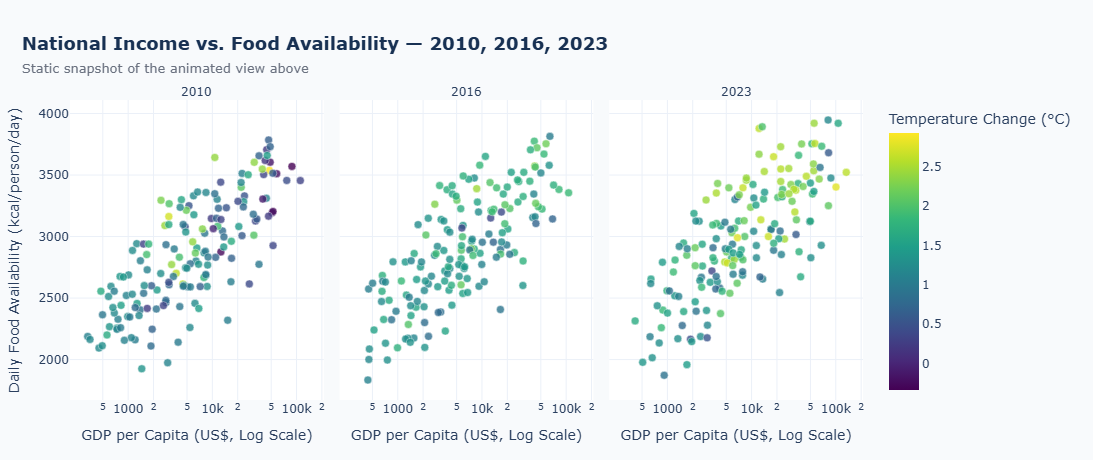

In [36]:
# ==========================================================
# AQ1 - Static Snapshot (2010 / 2016 / 2023) for PDF/print export
# ==========================================================

snapshot_years = [2010, 2016, 2023]
aq1_snapshot = aq1_df[aq1_df["Year"].isin(snapshot_years)]

fig_static = px.scatter(
    aq1_snapshot,
    x="GDP_per_Capita",
    y="Calories_per_Capita",
    color="Temperature_Change",
    facet_col="Year",
    hover_name="Country",
    log_x=True,
    color_continuous_scale="Viridis",
    labels={
        "GDP_per_Capita": "GDP per Capita (US$, Log Scale)",
        "Calories_per_Capita": "Daily Food Availability (kcal/person/day)",
        "Temperature_Change": "Temperature Change (°C)"
    }
)

fig_static.update_traces(marker=dict(size=8, opacity=0.8, line=dict(width=0.5, color="white")))

fig_static.update_layout(
    template="plotly_white",
    height=460,
    paper_bgcolor=BG,
    plot_bgcolor="white",
    title=dict(
        text="<b>National Income vs. Food Availability — 2010, 2016, 2023</b>"
             "<br><span style='font-size:13px;color:#6B7280'>Static snapshot of the animated view above</span>",
        x=0.02, font=dict(size=18, color=COLOR_NAVY)
    ),
    margin=dict(l=70, r=40, t=100, b=60)
)
fig_static.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))

fig_static.show(config={"displayModeBar": False})

In [37]:
# ==========================================================
# AQ1 - Correlation
# ==========================================================

corr = aq1_df[
    ["GDP_per_Capita","Calories_per_Capita"]
].corr()

display(corr)

,GDP_per_Capita,Calories_per_Capita
GDP_per_Capita,1.000000,0.605434
Calories_per_Capita,0.605434,1.000000


### Key Insight

Higher-income countries generally provide greater calorie availability, and the relationship holds broadly across the 2010–2023 panel. However, it is not perfectly linear — several middle-income countries achieve calorie levels comparable to wealthier nations, showing that GDP alone does not fully determine food security outcomes.

**Business Insight**

Policymakers and development funders should not treat GDP growth as a sufficient food-security strategy on its own; targeted investment in agriculture, trade infrastructure, and distribution can close the gap for middle-income countries faster than income growth alone.

---

## Analytical Question 2

### How strongly is temperature change associated with food availability across countries?

Climate change is widely expected to threaten agricultural productivity and food systems. Before assuming a uniform climate penalty on food security, it's necessary to test whether countries experiencing larger warming actually show measurably lower food availability.

**Goal:** Assess whether countries with larger annual temperature increases tend to have lower daily calorie availability, using GDP as an added lens on the relationship.

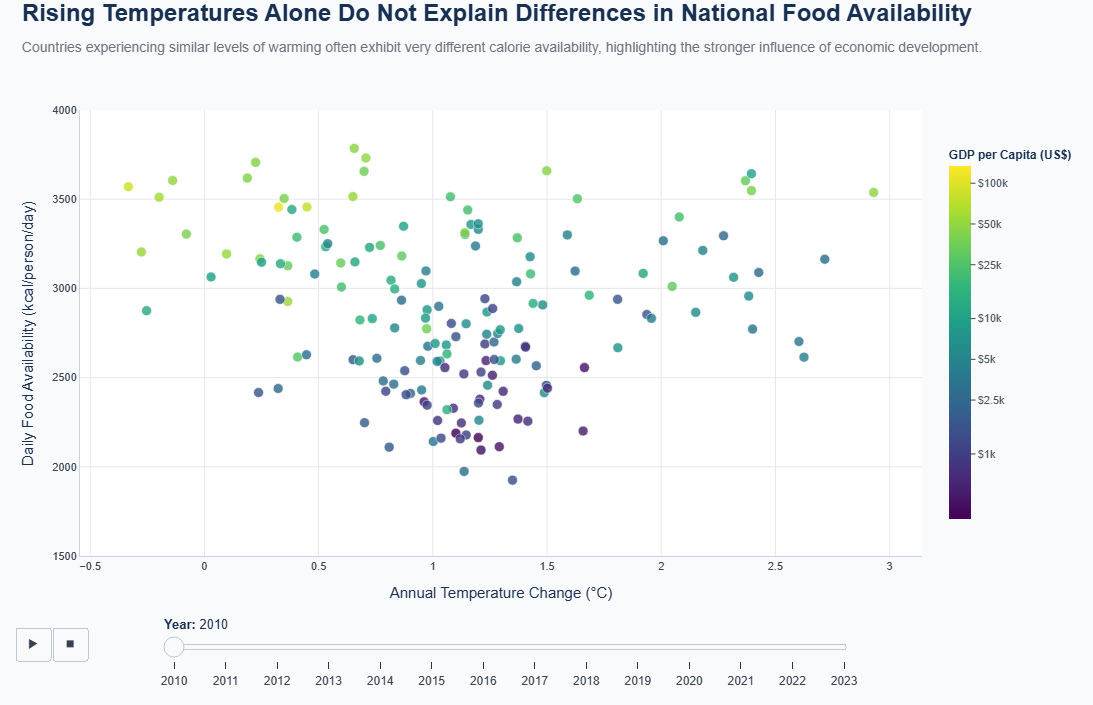

In [38]:
# ==========================================================
# AQ2
# Does Climate Change Reduce National Food Availability?
# ==========================================================

import numpy as np
import plotly.express as px

# ----------------------------------------------------------
# Data Preparation
# ----------------------------------------------------------

aq2_df = (
    analysis_df
    .query("Item == 'Grand Total'")
    .dropna(
        subset=[
            "Temperature_Change",
            "Calories_per_Capita",
            "GDP_per_Capita"
        ]
    )
    .copy()
)
aq2_df.sort_values("Year", inplace=True)

# ----------------------------------------------------------
# Log-transform GDP for balanced colour mapping
# ----------------------------------------------------------

aq2_df["Log_GDP"] = np.log10(aq2_df["GDP_per_Capita"])

log_min = aq2_df["Log_GDP"].min()
log_max = aq2_df["Log_GDP"].max()

tick_values = [
    1000,
    2500,
    5000,
    10000,
    25000,
    50000,
    100000
]

log_tick_values = [np.log10(i) for i in tick_values]

tick_text = [
    "$1k",
    "$2.5k",
    "$5k",
    "$10k",
    "$25k",
    "$50k",
    "$100k"
]

# ----------------------------------------------------------
# Build Scatter Plot
# ----------------------------------------------------------

fig = px.scatter(
    aq2_df,
    x="Temperature_Change",
    y="Calories_per_Capita",
    color="Log_GDP",
    animation_frame="Year",
    hover_name="Country",
    range_color=[log_min, log_max],
    color_continuous_scale="Viridis",
    labels={
        "Temperature_Change":
        "Annual Temperature Change (°C)",
        "Calories_per_Capita":
        "Daily Food Availability (kcal/person/day)"
    },
    hover_data={
        "GDP_per_Capita":":$,.0f",
        "Calories_per_Capita":":.0f",
        "Temperature_Change":":.2f",
        "Log_GDP":False
    }
)

# ----------------------------------------------------------
# Marker Styling
# ----------------------------------------------------------
fig.update_traces(
    marker=dict(
        size=10,
        opacity=0.82,
        line=dict(
            width=0.6,
            color="white"
        )
    ),
    selector=dict(mode="markers")
)

# ----------------------------------------------------------
# Executive Layout
# ----------------------------------------------------------
fig.update_layout(
    template="plotly_white",
    width=1120,
    height=690,
    paper_bgcolor=BG,
    plot_bgcolor="white",
    margin=dict(
        l=80,
        r=70,
        t=110,
        b=80
    ),

    font=dict(
        family="Arial",
        size=12,
        color="#374151"
    ),

    title=dict(
        text=(
            "<b>Rising Temperatures Alone Do Not Explain Differences in National Food Availability</b>"
            "<br>"
            "<span style='font-size:14px;color:#6B7280;'>"
            "Countries experiencing similar levels of warming often exhibit very different calorie availability, "
            "highlighting the stronger influence of economic development."
            "</span>"
        ),
        x=0.02,
        y=0.97,
        xanchor="left",
        font=dict(
            family="Arial",
            size=24,
            color=COLOR_NAVY
        )
    ),

    xaxis=dict(
        title="Annual Temperature Change (°C)",
        title_font=dict(
            size=15,
            color=COLOR_NAVY
        ),
        tickfont=dict(size=11),
        showgrid=True,
        gridcolor=COLOR_GRID,
        zeroline=False,
        linecolor="#CBD5E1"
    ),
    yaxis=dict(
        title="Daily Food Availability (kcal/person/day)",
        title_font=dict(
            size=15,
            color=COLOR_NAVY
        ),
        tickfont=dict(size=11),
        showgrid=True,
        gridcolor=COLOR_GRID,
        zeroline=False,
        linecolor="#CBD5E1",
        range=[1500,4000]
    )
)

# ----------------------------------------------------------
# Executive Colour Scale & Animation Controls
# ----------------------------------------------------------
fig.update_layout(
    coloraxis_colorbar=dict(
        title=dict(
            text="<b>GDP per Capita (US$)</b>",
            side="top",
            font=dict(
                size=12,
                color=COLOR_NAVY
            )
        ),
        tickvals=log_tick_values,
        ticktext=tick_text,
        tickfont=dict(
            size=11,
            color="#4B5563"
        ),
        ticks="outside",
        ticklen=5,
        tickwidth=1,
        thickness=22,
        thicknessmode="pixels",
        len=0.88,
        lenmode="fraction",
        y=0.50,
        yanchor="middle",
        x=1.02,
        outlinewidth=0
    ),
    sliders=[
        dict(
            active=0,
            x=0.10,
            y=-0.08,
            len=0.82,
            currentvalue=dict(
                prefix="<b>Year:</b> ",
                font=dict(
                    size=13,
                    color=COLOR_NAVY
                )
            ),
            pad=dict(
                t=20
            )
        )
    ]
)

# ----------------------------------------------------------
# Executive Hover Card
# ----------------------------------------------------------
fig.update_traces(
    hovertemplate=
    "<b>%{hovertext}</b><br><br>"
    "Temperature Change: <b>%{x:.2f} °C</b><br>"
    "Daily Calories: <b>%{y:.0f} kcal</b><br>"
    "GDP per Capita: <b>$%{customdata[0]:,.0f}</b>"
    "<extra></extra>",
    customdata=aq2_df[["GDP_per_Capita"]]
)

# ==========================================================
# Final Executive Presentation Refinements
# ==========================================================

# Smooth animation
fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 800
fig.layout.updatemenus[0].buttons[0].args[1]["transition"]["duration"] = 500
fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["redraw"] = True

# Position Play Button
fig.layout.updatemenus[0].pad = dict(r=10, t=35)
fig.layout.updatemenus[0].x = 0.02
fig.layout.updatemenus[0].y = -0.08

# Clean hover styling
fig.update_layout(
    hoverlabel=dict(
        bgcolor="white",
        bordercolor="#D1D5DB",
        font=dict(
            family="Arial",
            size=12,
            color="#374151"
        )
    )
)

# Remove spike lines
fig.update_xaxes(
    showspikes=False,
    showline=True,
    linewidth=1,
    linecolor="#CBD5E1"
)

fig.update_yaxes(
    showspikes=False,
    showline=True,
    linewidth=1,
    linecolor="#CBD5E1"
)

# Better marker rendering
fig.update_traces(

    marker=dict(
        sizemode="diameter"
    )

)

# Disable Plotly toolbar
config = dict(
    displaylogo=False,
    displayModeBar=False,
    responsive=True
)

fig.show(config=config)

**Static snapshot** (for PDF / slide export, where the animation above renders as a single frame):

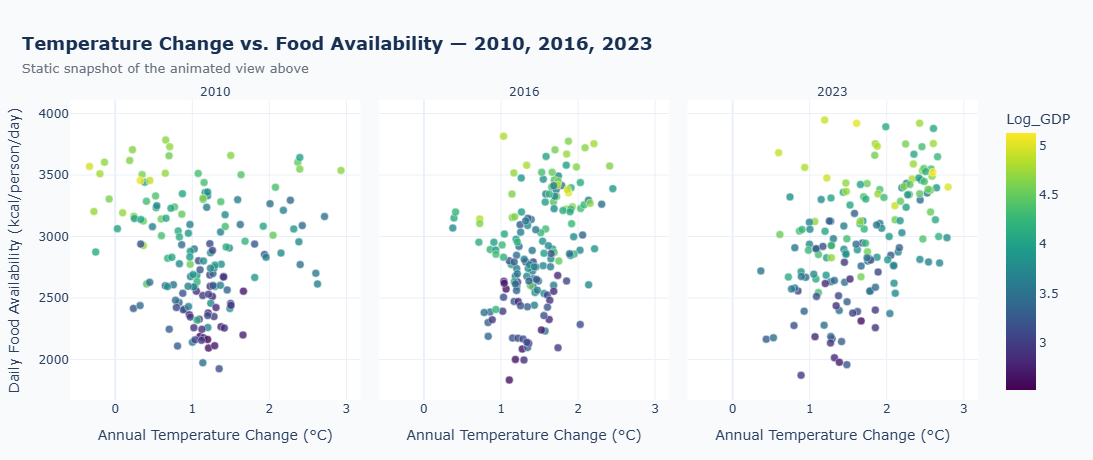

In [39]:
# ==========================================================
# AQ2 - Static Snapshot (2010 / 2016 / 2023) for PDF/print export
# ==========================================================

aq2_snapshot = aq2_df[aq2_df["Year"].isin([2010, 2016, 2023])]

fig_static2 = px.scatter(
    aq2_snapshot,
    x="Temperature_Change",
    y="Calories_per_Capita",
    color="Log_GDP",
    facet_col="Year",
    hover_name="Country",
    range_color=[log_min, log_max],
    color_continuous_scale="Viridis",
    labels={
        "Temperature_Change": "Annual Temperature Change (°C)",
        "Calories_per_Capita": "Daily Food Availability (kcal/person/day)"
    }
)

fig_static2.update_traces(marker=dict(size=8, opacity=0.8, line=dict(width=0.5, color="white")))

fig_static2.update_layout(
    template="plotly_white",
    height=460,
    paper_bgcolor=BG,
    plot_bgcolor="white",
    title=dict(
        text="<b>Temperature Change vs. Food Availability — 2010, 2016, 2023</b>"
             "<br><span style='font-size:13px;color:#6B7280'>Static snapshot of the animated view above</span>",
        x=0.02, font=dict(size=18, color=COLOR_NAVY)
    ),
    margin=dict(l=70, r=40, t=100, b=60)
)
fig_static2.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))

fig_static2.show(config={"displayModeBar": False})

In [40]:
corr = aq2_df[
    ["Temperature_Change","Calories_per_Capita"]
].corr()

display(corr)

,Temperature_Change,Calories_per_Capita
Temperature_Change,1.000000,0.360537
Calories_per_Capita,0.360537,1.000000


### Key Insight

Countries experiencing greater temperature increases do not uniformly show lower food availability — the relationship is comparatively weak once viewed across the full country-year panel. Countries with similar warming levels often land at very different calorie levels, suggesting other factors dominate.

**Business Insight**

Climate-adaptation funding should not be allocated purely on exposure to warming; economic capacity and adaptive infrastructure are stronger predictors of food outcomes and should weight prioritization decisions alongside temperature data.

---

## Analytical Question 3

### Which factor shows a stronger relationship with food availability — economic prosperity or climate stress?

Understanding the *relative* strength of these two drivers, rather than evaluating them in isolation as in AQ1 and AQ2, gives more direct evidence for where policy attention and resources should be concentrated.

**Goal:** Compare the correlation strength of GDP per capita and of temperature change against daily calorie availability, to identify the dominant predictor.

In [41]:
# ==========================================================
# AQ3 - Compare Economic vs Climate Relationships
# Data Preparation
# ----------------------------------------------------------
# NOTE: correlation is computed on COUNTRY-LEVEL AVERAGES
# (2010-2023), not the pooled country-year panel. Pooling
# repeated observations per country would inflate the sample
# size artificially and understate the true relationship.
# GDP is log-transformed here, consistent with AQ1/AQ2, since
# GDP is heavily right-skewed and Pearson r on raw GDP
# understates its monotonic relationship with food availability.
# ==========================================================

aq3_df = (
    analysis_df
    .query("Item == 'Grand Total'")
    .dropna(
        subset=[
            "GDP_per_Capita",
            "Temperature_Change",
            "Calories_per_Capita"
        ]
    )
    .groupby("Country", as_index=False)
    .agg({
        "GDP_per_Capita": "mean",
        "Temperature_Change": "mean",
        "Calories_per_Capita": "mean"
    })
)

aq3_df["Log_GDP"] = np.log10(aq3_df["GDP_per_Capita"])

print(aq3_df.shape)
aq3_df.head()

(172, 5)


,Country,GDP_per_Capita,Temperature_Change,Calories_per_Capita,Log_GDP
0,Afghanistan,522.874223,1.204214,2241.839286,2.718397
1,Albania,5615.795731,1.576214,3290.974286,3.749411
2,Algeria,4991.592930,1.559714,3379.442143,3.698239
3,Angola,3630.432766,0.964286,2448.401429,3.559958
4,Antigua and Barbuda,16960.037181,0.794714,2438.833571,4.229427


In [42]:
# ==========================================================
# AQ3 - Build Correlation Comparison Dataset
# ==========================================================

corr_df = aq3_df[
    [
        "Log_GDP",
        "Temperature_Change",
        "Calories_per_Capita"
    ]
].copy()

corr_df.rename(
    columns={
        "Log_GDP": "GDP per Capita (log)",
        "Temperature_Change": "Temperature Change",
        "Calories_per_Capita": "Daily Calories"
    },
    inplace=True
)

corr_df.head()

,GDP per Capita (log),Temperature Change,Daily Calories
0,2.718397,1.204214,2241.839286
1,3.749411,1.576214,3290.974286
2,3.698239,1.559714,3379.442143
3,3.559958,0.964286,2448.401429
4,4.229427,0.794714,2438.833571


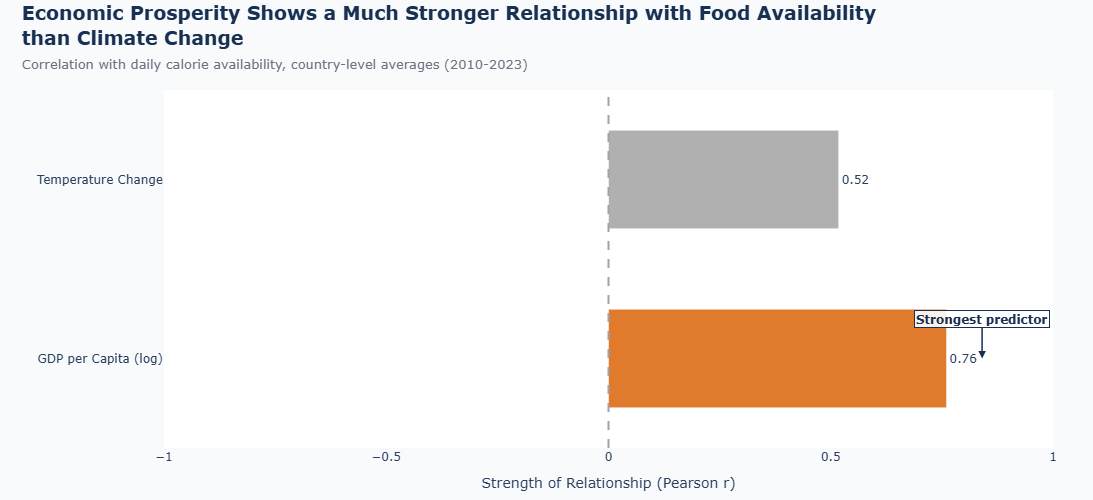

In [43]:
# ==========================================
# AQ3 - Strength of Relationship Comparison
# ==========================================

import plotly.graph_objects as go

gdp_corr = aq3_df["Log_GDP"].corr(
    aq3_df["Calories_per_Capita"]
)

temp_corr = aq3_df["Temperature_Change"].corr(
    aq3_df["Calories_per_Capita"]
)

comparison = pd.DataFrame({
    "Driver": [
        "GDP per Capita (log)",
        "Temperature Change"
    ],
    "Correlation": [
        gdp_corr,
        temp_corr
    ]
})

comparison["Abs"] = comparison["Correlation"].abs()
comparison = comparison.sort_values(
    "Abs",
    ascending=False
)
colors = [HIGHLIGHT, CONTEXT_GREY]

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=comparison["Correlation"],
        y=comparison["Driver"],
        orientation="h",
        marker_color=colors,
        text=comparison["Correlation"].round(2),
        textposition="outside",
        width=0.55
    )
)

fig.add_vline(
    x=0,
    line_color="#9CA3AF",
    line_dash="dash"
)

fig.add_annotation(
    x=gdp_corr + 0.08,
    y="GDP per Capita (log)",
    text="<b>Strongest predictor</b>",
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=1.5,
    arrowcolor=COLOR_NAVY,
    ax=0,
    ay=-40,
    bgcolor="rgba(255,255,255,0.9)",
    bordercolor=COLOR_NAVY,
    borderwidth=1,
    font=dict(size=12, color=COLOR_NAVY)
)

fig.update_layout(
    template="plotly_white",
    paper_bgcolor=BG,
    plot_bgcolor="white",
    height=500,
    showlegend=False,
    title=dict(
        text="<b>Economic Prosperity Shows a Much Stronger Relationship with Food Availability</b>"
             "<br><b>than Climate Change</b>"
             "<br><span style='font-size:13px;color:#6B7280'>Correlation with daily calorie availability, country-level averages (2010-2023)</span>",
        x=0.02,
        y=0.96,
        font=dict(size=19, color=COLOR_NAVY)
    ),
    xaxis=dict(
        title="Strength of Relationship (Pearson r)",
        range=[-1, 1],
        showgrid=False,
        zeroline=False
    ),
    yaxis=dict(
        title=""
    ),
    margin=dict(l=140, r=40, t=90, b=50)
)

fig.show(config={"displayModeBar": False})

### Key Insight

Economic prosperity shows a substantially stronger positive relationship with food availability than annual temperature change does, using country-level averages and a consistent log-GDP transform to make the two comparisons fair. While GDP per capita is consistently associated with higher calorie availability, the temperature–calorie relationship is comparatively weak.

**Business Insight**

Given limited resources, food-security interventions anchored in economic development are likely to yield a larger measurable impact than climate-focused interventions alone — though the two should be treated as complementary, not substitutes.

---

## Analytical Question 4

### Which countries demonstrate the highest climate resilience while maintaining food security?

Aggregate correlations (AQ2, AQ3) can hide genuine outlier success stories. Identifying specific countries that sustain high food availability despite above-average warming turns a statistical pattern into concrete, actionable examples.

**Goal:** Identify countries that combine above-average temperature change with above-average daily calorie availability, using a quadrant analysis.

In [44]:
# ==========================================================
# AQ4 - Climate Resilient Countries
# Data Preparation
# ==========================================================

aq4_df = (
    analysis_df
    .query("Item == 'Grand Total'")
    .groupby("Country", as_index=False)
    .agg(
        Average_Calories=("Calories_per_Capita", "mean"),
        Average_Temperature=("Temperature_Change", "mean"),
        Average_GDP=("GDP_per_Capita", "mean")
    )
)

aq4_df = aq4_df.dropna()

print(aq4_df.shape)

aq4_df.head()

(172, 4)


,Country,Average_Calories,Average_Temperature,Average_GDP
0,Afghanistan,2241.839286,1.204214,522.874223
1,Albania,3290.974286,1.576214,5615.795731
2,Algeria,3379.442143,1.559714,4991.592930
3,Angola,2448.401429,0.964286,3630.432766
4,Antigua and Barbuda,2438.833571,0.794714,16960.037181


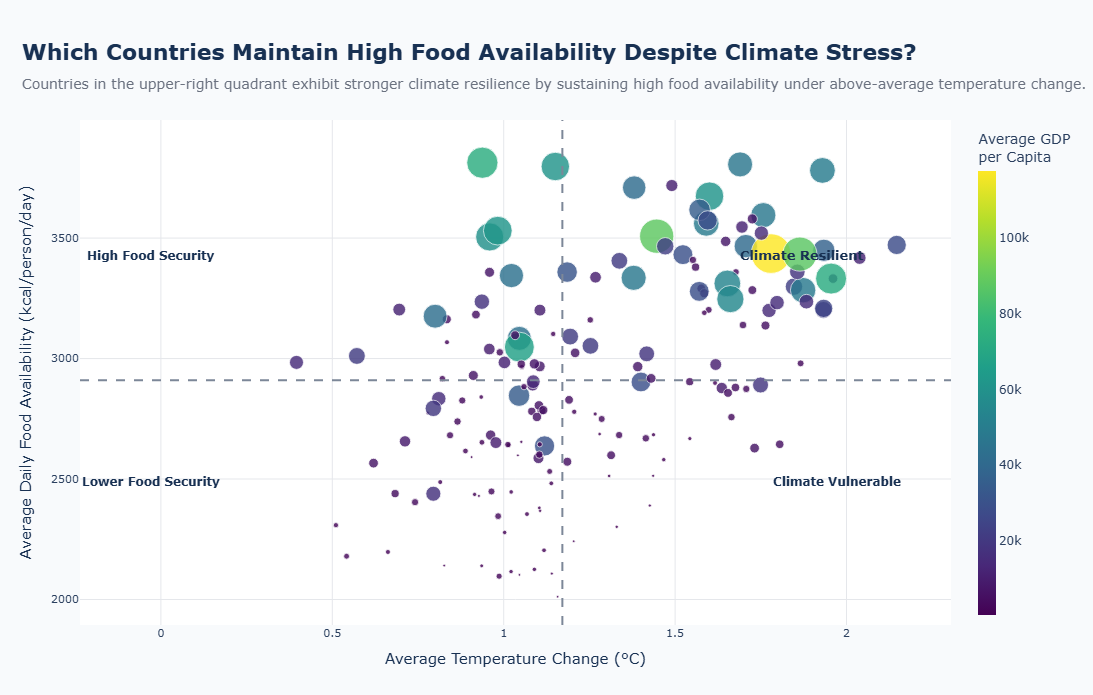

In [45]:
# ==========================================================
# AQ4 - Climate Resilience Quadrant Analysis
# ==========================================================

import plotly.express as px

# Median reference lines
temp_median = aq4_df["Average_Temperature"].median()
calorie_median = aq4_df["Average_Calories"].median()

fig = px.scatter(
    aq4_df,
    x="Average_Temperature",
    y="Average_Calories",
    size="Average_GDP",
    hover_name="Country",
    size_max=28,
    color="Average_GDP",
    color_continuous_scale="Viridis"
)

fig.update_traces(
    marker=dict(
        opacity=0.82,
        line=dict(
            color="white",
            width=0.8
        )
    )
)

# Quadrant Lines
fig.add_vline(
    x=temp_median,
    line_dash="dash",
    line_color="#7C8798",
    line_width=2
)

fig.add_hline(
    y=calorie_median,
    line_dash="dash",
    line_color="#7C8798",
    line_width=2
)

# Quadrant Labels
fig.add_annotation(
    x=temp_median+0.7,
    y=calorie_median+520,
    text="<b>Climate Resilient</b>",
    showarrow=False,
    font=dict(size=13,color="#183153")
)

fig.add_annotation(
    x=temp_median-1.2,
    y=calorie_median+520,
    text="<b>High Food Security</b>",
    showarrow=False,
    font=dict(size=12,color="#183153")
)

fig.add_annotation(
    x=temp_median+0.8,
    y=calorie_median-420,
    text="<b>Climate Vulnerable</b>",
    showarrow=False,
    font=dict(size=12,color="#183153")
)

fig.add_annotation(
    x=temp_median-1.2,
    y=calorie_median-420,
    text="<b>Lower Food Security</b>",
    showarrow=False,
    font=dict(size=12,color="#183153")
)

fig.update_layout(

    template="plotly_white",

    width=1100,
    height=680,

    paper_bgcolor=BG,
    plot_bgcolor="white",

    title=dict(
        text="<b>Which Countries Maintain High Food Availability Despite Climate Stress?</b>"
             "<br><span style='font-size:14px;color:#6B7280'>Countries in the upper-right quadrant exhibit stronger climate resilience by sustaining high food availability under above-average temperature change.</span>",
        x=0.02,
        font=dict(
            size=22,
            color="#183153"
        )
    ),

    xaxis=dict(
        title="Average Temperature Change (°C)",
        title_font=dict(size=15,color="#183153"),
        tickfont=dict(size=11),
        gridcolor=COLOR_GRID,
        zeroline=False
    ),

    yaxis=dict(
        title="Average Daily Food Availability (kcal/person/day)",
        title_font=dict(size=15,color="#183153"),
        tickfont=dict(size=11),
        gridcolor=COLOR_GRID,
        zeroline=False
    ),

    coloraxis_colorbar=dict(
        title=dict(
            text="Average GDP<br>per Capita",
            side="top"
        ),
        thickness=18
    ),

    margin=dict(
        l=80,
        r=80,
        t=120,
        b=70
    )
)

fig.show(config={"displayModeBar":False})

In [46]:
# ==========================================================
# AQ4 - Top Climate-Resilient Countries
# ==========================================================

climate_resilient = (
    aq4_df[
        (aq4_df["Average_Temperature"] >= temp_median) &
        (aq4_df["Average_Calories"] >= calorie_median)
    ]
    .sort_values(
        ["Average_Calories", "Average_Temperature"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

top10_resilient = climate_resilient.head(10)

display(top10_resilient)

print(f"Climate Resilient Countries Identified: {len(climate_resilient)}")


,Country,Average_Calories,Average_Temperature,Average_GDP
0,Belgium,3805.802857,1.689571,46874.430709
1,Austria,3780.822143,1.929714,49721.474110
2,Turkiye,3718.077857,1.490429,10973.705573
3,Israel,3709.517857,1.380643,41435.492099
4,Denmark,3673.882143,1.600357,61018.034913
5,Italy,3617.189286,1.571357,34881.509851
6,Germany,3595.167857,1.757357,47353.199505
7,Serbia,3579.618571,1.725214,7642.524106
8,Saudi Arabia,3573.345000,1.594929,28061.873351
9,Canada,3560.887143,1.590786,49063.242249


Climate Resilient Countries Identified: 58


In [47]:
# ==========================================================
# AQ4 - Executive Summary Table
# ==========================================================

summary_table = (
    top10_resilient[
        [
            "Country",
            "Average_Calories",
            "Average_Temperature",
            "Average_GDP"
        ]
    ]
    .copy()
)

summary_table.columns = [
    "Country",
    "Daily Calories",
    "Temperature Change (°C)",
    "GDP per Capita (USD)"
]

summary_table["Daily Calories"] = (
    summary_table["Daily Calories"]
    .round(0)
    .astype(int)
)

summary_table["Temperature Change (°C)"] = (
    summary_table["Temperature Change (°C)"]
    .round(2)
)

summary_table["GDP per Capita (USD)"] = (
    summary_table["GDP per Capita (USD)"]
    .round(0)
)

display(summary_table)


,Country,Daily Calories,Temperature Change (°C),GDP per Capita (USD)
0,Belgium,3806,1.69,46874.0
1,Austria,3781,1.93,49721.0
2,Turkiye,3718,1.49,10974.0
3,Israel,3710,1.38,41435.0
4,Denmark,3674,1.60,61018.0
5,Italy,3617,1.57,34882.0
6,Germany,3595,1.76,47353.0
7,Serbia,3580,1.73,7643.0
8,Saudi Arabia,3573,1.59,28062.0
9,Canada,3561,1.59,49063.0


### Key Insight

A distinct group of countries maintains high food availability despite experiencing above-average temperature increases. These climate-resilient countries tend to combine stronger economic capacity, agricultural productivity, and adaptive infrastructure.

**Business Insight**

These upper-right-quadrant countries are strong candidates for detailed case studies — replicable elements of their resilience strategy (trade diversification, agri-tech adoption, buffer stocks) can inform aid and investment design for climate-vulnerable, lower-income countries.

---

## Analytical Question 5

### Which food groups contribute the most to global calorie availability?

Food security depends not only on total calorie quantity but on the composition of the supply. Knowing which food groups the world's diet actually depends on identifies where supply-chain disruption risk is concentrated.

**Goal:** Rank food groups by their cumulative contribution to global calorie availability between 2010 and 2023.

In [48]:
# ==========================================================
# AQ5 - Global Calorie Contribution by Food Group
# Data Preparation
# ----------------------------------------------------------

AGGREGATE_ITEMS = [
    "Vegetal Products",       # top-level aggregate (sums everything below)
    "Animal Products",        # top-level aggregate (sums everything below)
    "Cereals - Excluding Beer",  # aggregate of Wheat/Rice/Maize
    "Sugar & Sweeteners",     # aggregate of Sugar (Raw Equivalent)
    "Meat"                    # aggregate of Poultry Meat
]

aq5_df = (
    analysis_df
    .query("Item != 'Grand Total'")
    .query("Item not in @AGGREGATE_ITEMS")
    .groupby("Item", as_index=False)
    .agg(
        Total_Calories=("Calories_per_Capita", "sum")
    )
)

aq5_df = (
    aq5_df
    .dropna()
    .sort_values(
        "Total_Calories",
        ascending=False
    )
)

print(aq5_df.shape)
aq5_df.head()

(113, 2)


,Item,Total_Calories
110,Wheat and products,1326513.89
107,Vegetable Oils,754409.83
82,Rice and products,725436.35
95,Sugar (Raw Equivalent),624832.83
50,Milk - Excluding Butter,459434.65


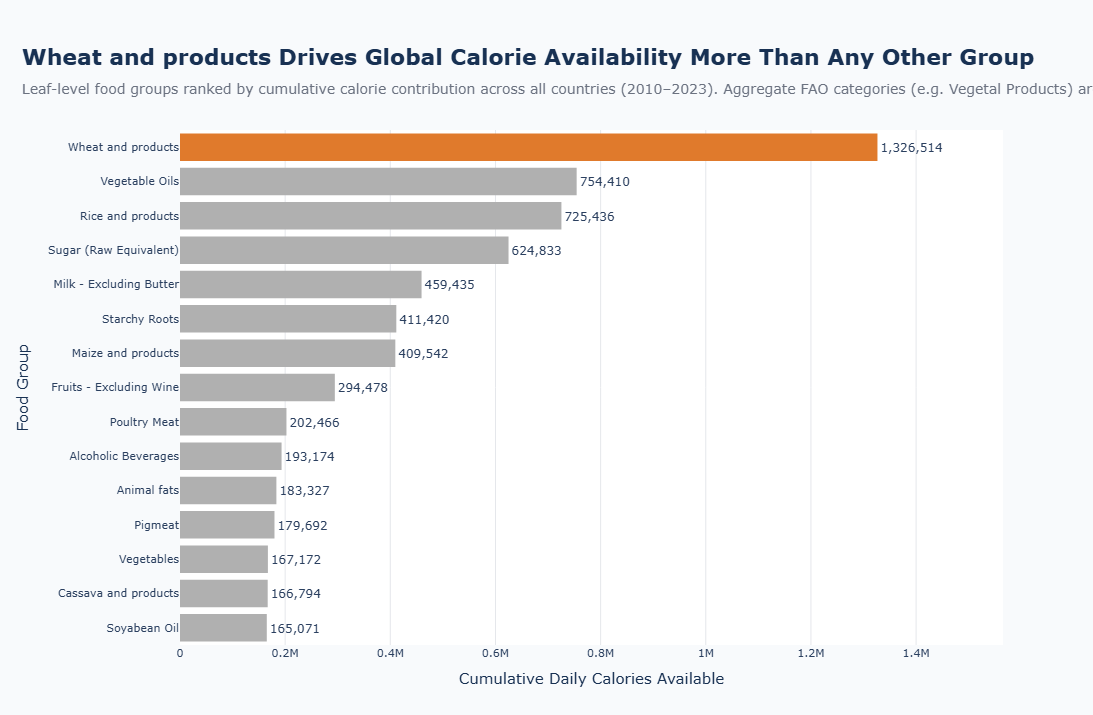

In [49]:
# ==========================================================
# AQ5 - Top Food Groups Driving Global Calorie Availability
# ==========================================================

import plotly.express as px

top_foods = (
    aq5_df
    .head(15)
    .sort_values("Total_Calories")
)

n_items = len(top_foods)
leading_item = top_foods.iloc[-1]["Item"]
leading_value = top_foods.iloc[-1]["Total_Calories"]

# Flat context colour for all bars, with the single highlight
# colour reserved for the #1 contributor - color no longer
# duplicates the same information already shown by bar length.
bar_colors = [CONTEXT_GREY] * (n_items - 1) + [HIGHLIGHT]

fig = px.bar(
    top_foods,
    x="Total_Calories",
    y="Item",
    orientation="h",
    text="Total_Calories"
)

fig.update_traces(
    marker_color=bar_colors,
    texttemplate="%{text:,.0f}",
    textposition="outside",
    marker_line_width=0,
    cliponaxis=False   # let the outside text label draw past the bar without being clipped
)

# Reserve explicit headroom on the x-axis so the longest bar's
# outside label never overflows the plotting area (this is what
# caused the "5,645,..." label to get cut off previously).
x_max = top_foods["Total_Calories"].max()

fig.update_layout(
    template="plotly_white",
    width=1150,
    height=700,
    paper_bgcolor=BG,
    plot_bgcolor="white",
    title=dict(
        text=f"<b>{leading_item} Drives Global Calorie Availability More Than Any Other Group</b>"
             f"<br><span style='font-size:14px;color:#6B7280'>Leaf-level food groups ranked by cumulative calorie contribution across all countries (2010–2023). Aggregate FAO categories (e.g. Vegetal Products) are excluded to avoid double-counting.</span>",
        x=0.02,
        font=dict(
            size=22,
            color=COLOR_NAVY
        )
    ),

    xaxis=dict(
        title="Cumulative Daily Calories Available",
        title_font=dict(
            size=15,
            color=COLOR_NAVY
        ),
        tickfont=dict(size=11),
        gridcolor=COLOR_GRID,
        zeroline=False,
        range=[0, x_max * 1.18]   # headroom for the outside text label
    ),

    yaxis=dict(
        title="Food Group",
        title_font=dict(
            size=15,
            color=COLOR_NAVY
        ),
        tickfont=dict(size=11),
        categoryorder="total ascending"
    ),

    showlegend=False,

    margin=dict(
        l=180,
        r=90,
        t=130,
        b=70
    )
)

fig.show(config={"displayModeBar":False})

In [50]:
# ==========================================================
# AQ5 - Percentage Contribution
# ==========================================================

aq5_percent = aq5_df.copy()

aq5_percent["Contribution (%)"] = (
    aq5_percent["Total_Calories"] /
    aq5_percent["Total_Calories"].sum()
) * 100

top15_percent = (
    aq5_percent
    .head(15)
    [
        [
            "Item",
            "Total_Calories",
            "Contribution (%)"
        ]
    ]
)

top15_percent["Contribution (%)"] = (
    top15_percent["Contribution (%)"]
    .round(2)
)

display(top15_percent)


,Item,Total_Calories,Contribution (%)
110,Wheat and products,1326513.89,13.93
107,Vegetable Oils,754409.83,7.92
82,Rice and products,725436.35,7.62
95,Sugar (Raw Equivalent),624832.83,6.56
50,Milk - Excluding Butter,459434.65,4.82
93,Starchy Roots,411419.67,4.32
46,Maize and products,409542.15,4.30
36,Fruits - Excluding Wine,294478.49,3.09
77,Poultry Meat,202466.44,2.13
1,Alcoholic Beverages,193173.65,2.03


### Key Insight

A relatively small number of food groups — led by cereals and other staples — account for the majority of global calorie availability. This concentration means disruptions to staple crop production or supply chains carry disproportionate risk to worldwide food security.

**Business Insight**

Organizations focused on food-system resilience should prioritize protecting and diversifying staple-crop supply chains specifically, rather than spreading resilience investment evenly across all food categories.

In [51]:
# ==========================================================
# Diagnostic — where do trade-flow fields actually have data?
# ==========================================================

check = (
    analysis_df
    .groupby("Item")[["Imports", "Domestic_Supply", "Calories_per_Capita"]]
    .apply(lambda d: d.notna().mean())
    .round(2)
)

print(check.loc[["Vegetal Products", "Animal Products"]])
print()
print("Sample of granular items:")
print(check.drop(index=["Vegetal Products", "Animal Products"]).head(10))

                  Imports  Domestic_Supply  Calories_per_Capita
Item                                                           
Vegetal Products      0.0              0.0                  1.0
Animal Products       0.0              0.0                  1.0

Sample of granular items:
                         Imports  Domestic_Supply  Calories_per_Capita
Item                                                                  
Alcohol, Non-Food           0.98              1.0                 0.00
Alcoholic Beverages         1.00              1.0                 0.99
Animal fats                 1.00              1.0                 1.00
Apples and products         1.00              1.0                 1.00
Aquatic Animals, Others     0.95              1.0                 0.91
Aquatic Plants              0.99              1.0                 0.01
Aquatic Products, Other     0.99              1.0                 0.01
Bananas                     0.88              1.0                 0.99
Barley 

In [52]:
# ==========================================================
# National Aggregation — rebuilt from granular commodity items
# ==========================================================

FAO_AGGREGATE_ITEMS = ["Grand Total", "Vegetal Products", "Animal Products"]

granular_df = analysis_df[~analysis_df["Item"].isin(FAO_AGGREGATE_ITEMS)].copy()

national_df = (
    granular_df
    .groupby(["Country", "Year"], as_index=False)
    .agg(
        Calories_per_Capita=("Calories_per_Capita", "sum"),
        Food_kg_per_Capita=("Food_kg_per_Capita", "sum"),
        Domestic_Supply=("Domestic_Supply", "sum"),
        Production=("Production", "sum"),
        Imports=("Imports", "sum"),
        Exports=("Exports", "sum"),
        Temperature_Change=("Temperature_Change", "mean"),
        GDP_per_Capita=("GDP_per_Capita", "mean"),
        Population=("Population", "mean"),
        Agricultural_Land_Percent=("Agricultural_Land_Percent", "mean"),
    )
)

print("Shape:", national_df.shape)
print(national_df[["Imports", "Domestic_Supply", "Calories_per_Capita"]].describe())
assert national_df["Domestic_Supply"].gt(0).any(), "Still zero — stop and inspect further."

Shape: (2397, 12)
             Imports  Domestic_Supply  Calories_per_Capita
count    2397.000000     2.397000e+03          2397.000000
mean    18841.595745     1.242540e+05          5595.133154
std     43906.111651     4.328559e+05           790.330941
min         8.000000     2.100000e+01          3454.800000
25%      1629.000000     5.724000e+03          5014.060000
50%      5359.000000     2.381400e+04          5630.670000
75%     16522.000000     6.824500e+04          6190.170000
max    584580.000000     4.930103e+06          7447.190000


---

## Analytical Question 6

### Does greater dependence on food imports improve national food availability?

Countries increasingly rely on international trade to meet domestic food demand. Because wealthier countries also tend to trade more, this analysis needs to isolate the trade effect from the income effect rather than conflate the two.

**Goal:** Determine whether higher import dependency is associated with better food availability after controlling for what GDP per capita alone would predict.

In [53]:
# ==========================================================
# AQ6 - Control for GDP before comparing reliance tiers
# ==========================================================

import numpy as np

aq6_df = national_df.dropna(subset=["Imports", "Domestic_Supply", "Calories_per_Capita", "GDP_per_Capita"]).copy()
aq6_df = aq6_df[(aq6_df["Domestic_Supply"] > 0) & (aq6_df["GDP_per_Capita"] > 0)]

aq6_df["Import_Dependency_Ratio"] = aq6_df["Imports"] / aq6_df["Domestic_Supply"] * 100
aq6_df["Reliance_Tier"] = pd.qcut(
    aq6_df["Import_Dependency_Ratio"], 3,
    labels=["Low Reliance", "Moderate Reliance", "High Reliance"], duplicates="drop"
)

# fit Calories ~ log(GDP) — the relationship GDP alone predicts
log_gdp = np.log(aq6_df["GDP_per_Capita"])
coeffs = np.polyfit(log_gdp, aq6_df["Calories_per_Capita"], 1)
aq6_df["Predicted_by_GDP"] = np.polyval(coeffs, log_gdp)

# residual = actual availability MINUS what income alone would predict
# positive residual = better fed than income predicts; negative = worse
aq6_df["Calorie_Residual"] = aq6_df["Calories_per_Capita"] - aq6_df["Predicted_by_GDP"]

aq6_summary = (
    aq6_df.groupby("Reliance_Tier", as_index=False, observed=True)
    .agg(Mean_Residual=("Calorie_Residual", "mean"),
         SEM=("Calorie_Residual", "sem"),
         Mean_GDP=("GDP_per_Capita", "mean"))
)
aq6_summary["CI95"] = aq6_summary["SEM"] * 1.96
print(aq6_summary)

       Reliance_Tier  Mean_Residual        SEM      Mean_GDP       CI95
0       Low Reliance      76.204570  19.305440   5653.964704  37.838662
1  Moderate Reliance      72.035457  18.725981  10911.161035  36.702922
2      High Reliance    -148.058805  19.291294  27857.786209  37.810936


In [36]:
# ==========================================================
# Confound check — does the "High Reliance" tier just mean "rich"?
# ==========================================================

aq6_check = (
    aq6_df
    .groupby("Reliance_Tier", observed=True)["GDP_per_Capita"]
    .mean()
    .round(0)
)
print(aq6_check)

Reliance_Tier
Low Reliance          5752.0
Moderate Reliance    10775.0
High Reliance        27841.0
Name: GDP_per_Capita, dtype: float64


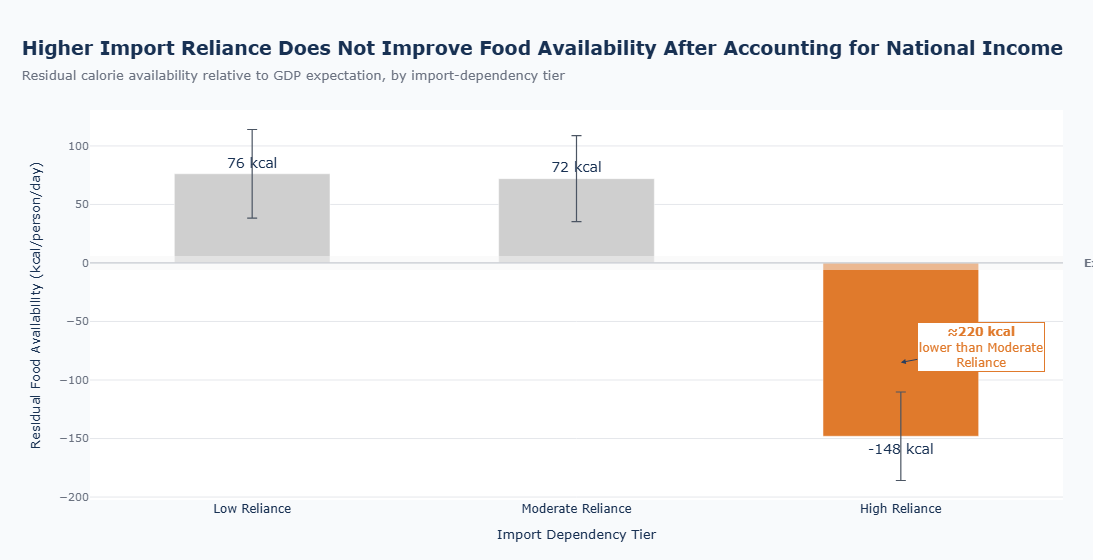

In [54]:
# ==========================================================
# AQ6 - Final Chart (reflects the actual residual finding)
# ==========================================================

import plotly.graph_objects as go

bar_colors = ["#CFCFCF", "#CFCFCF", HIGHLIGHT]
gap = aq6_summary.loc[1, "Mean_Residual"] - aq6_summary.loc[2, "Mean_Residual"]

fig = go.Figure()
fig.add_trace(go.Bar(
    x=aq6_summary["Reliance_Tier"], y=aq6_summary["Mean_Residual"],
    error_y=dict(type="data", array=aq6_summary["CI95"], color="#4B5563", thickness=1.2, width=5),
    marker_color=bar_colors,
    text=aq6_summary["Mean_Residual"].round(0).astype(int).astype(str) + " kcal",
    textposition="outside", textfont=dict(size=14, color=COLOR_NAVY), width=0.48
))

fig.add_hline(y=0, line_color="#9CA3AF", line_width=1.2)

fig.add_hrect(
    y0=-6,
    y1=6,
    fillcolor="#F5F5F5",
    opacity=0.5,
    line_width=0
)

fig.add_annotation(
    x=1.02,
    y=0,
    xref="paper",
    yref="y",
    text="<b>Expected from GDP</b>",
    showarrow=False,
    xanchor="left",
    font=dict(
        size=11,
        color="#6B7280"
    )
)

fig.add_annotation(
    x="High Reliance",
    y=-85,
    text="<b>≈220 kcal</b><br>lower than Moderate<br>Reliance",
    showarrow=True,
    arrowhead=2,
    ax=80,
    ay=-15,
    bgcolor="white",
    bordercolor=HIGHLIGHT,
    borderwidth=1,
    font=dict(
        size=12,
        color=HIGHLIGHT
    )
)

fig.update_layout(
    template="plotly_white",
    height=560,
    bargap=0.45,
    paper_bgcolor=BG, plot_bgcolor="white", showlegend=False,
    title=dict(
        text="<b>Higher Import Reliance Does Not Improve Food Availability After Accounting for National Income</b>"
             "<br><span style='font-size:13px;color:#6B7280'>Residual calorie availability relative to GDP expectation, by import-dependency tier</span>",
        x=0.02, font=dict(size=19, color=COLOR_NAVY)
    ),
    xaxis=dict(title="Import Dependency Tier", title_font=dict(size=13, color=COLOR_NAVY),
               tickfont=dict(size=12, color=COLOR_NAVY), showgrid=False, zeroline=False),
    yaxis=dict(title="Residual Food Availability (kcal/person/day)",
               title_font=dict(size=13, color=COLOR_NAVY), tickfont=dict(size=11, color=COLOR_SUB),
               gridcolor=COLOR_GRID, zeroline=False),
    margin=dict(l=90, r=30, t=110, b=60)
)

fig.show(config={"displayModeBar": False, "displaylogo": False})


### Key Insight

After removing the portion of food availability explained by GDP, countries in the highest import-dependency tier show meaningfully lower residual calorie availability (roughly 220 kcal/person/day less) than moderate-reliance countries. Trade dependence is not, on its own, a reliable path to better food security.

**Business Insight**

Governments and investors should treat heavy import reliance as a food-security risk factor to actively manage — through strategic reserves or domestic production support — rather than assuming that trade access alone secures supply.

---

## Analytical Question 7

### Does higher domestic food production lead to greater national food availability?

Trade can supplement supply, but long-term food security also depends on domestic production capacity. This question tests whether producing more food domestically actually translates into better-fed populations.

**Goal:** Examine whether countries with higher per-capita domestic food production also achieve higher daily calorie availability.

In [55]:
# ==========================================================
# AQ7 - Data Preparation
# ==========================================================

aq7_df = national_df.dropna(subset=["Production", "Calories_per_Capita", "Population"]).copy()
aq7_df = aq7_df[(aq7_df["Production"] > 0) & (aq7_df["Population"] > 0)]

aq7_country = (
    aq7_df.groupby("Country", as_index=False)
    .agg(Production=("Production", "mean"),
         Population=("Population", "mean"),
         Calories_per_Capita=("Calories_per_Capita", "mean"))
)

# Production is in 1,000 tonnes → convert to kg, then divide by population
# for a genuine per-person figure, comparable across country sizes
aq7_country["Production_per_Capita_kg"] = (
    aq7_country["Production"] * 1_000_000 / aq7_country["Population"]
)

print(aq7_country[["Production_per_Capita_kg", "Calories_per_Capita"]].describe())

       Production_per_Capita_kg  Calories_per_Capita
count                176.000000           176.000000
mean                2829.816075          5606.665856
std                 2376.623614           769.502235
min                   51.540578          3902.975000
25%                 1188.053411          5088.456607
50%                 2053.495133          5630.883214
75%                 3760.907210          6209.325571
max                12236.013918          7189.156429


In [56]:
# ==========================================================
# AQ7 - Identify concrete example countries that tell the story
# without requiring the reader to know what "r" means
# ==========================================================

# a country that produces very little per capita, yet is well fed
# (illustrates: trade/wealth can substitute for domestic production)
low_prod_examples = aq7_country.nsmallest(30, "Production_per_Capita_kg")
example_low_prod_high_cal = low_prod_examples.nlargest(1, "Calories_per_Capita").iloc[0]

# a country that produces a lot per capita, yet availability is only middling
# (illustrates: production alone doesn't guarantee it reaches people's plates)
high_prod_examples = aq7_country.nlargest(30, "Production_per_Capita_kg")
example_high_prod_low_cal = high_prod_examples.nsmallest(1, "Calories_per_Capita").iloc[0]

print(example_low_prod_high_cal[["Country", "Production_per_Capita_kg", "Calories_per_Capita"]])
print(example_high_prod_low_cal[["Country", "Production_per_Capita_kg", "Calories_per_Capita"]])

Country                     Saudi Arabia
Production_per_Capita_kg      592.952733
Calories_per_Capita          6929.072143
Name: 135, dtype: object
Country                         Eswatini
Production_per_Capita_kg    12174.678925
Calories_per_Capita          4686.350714
Name: 47, dtype: object


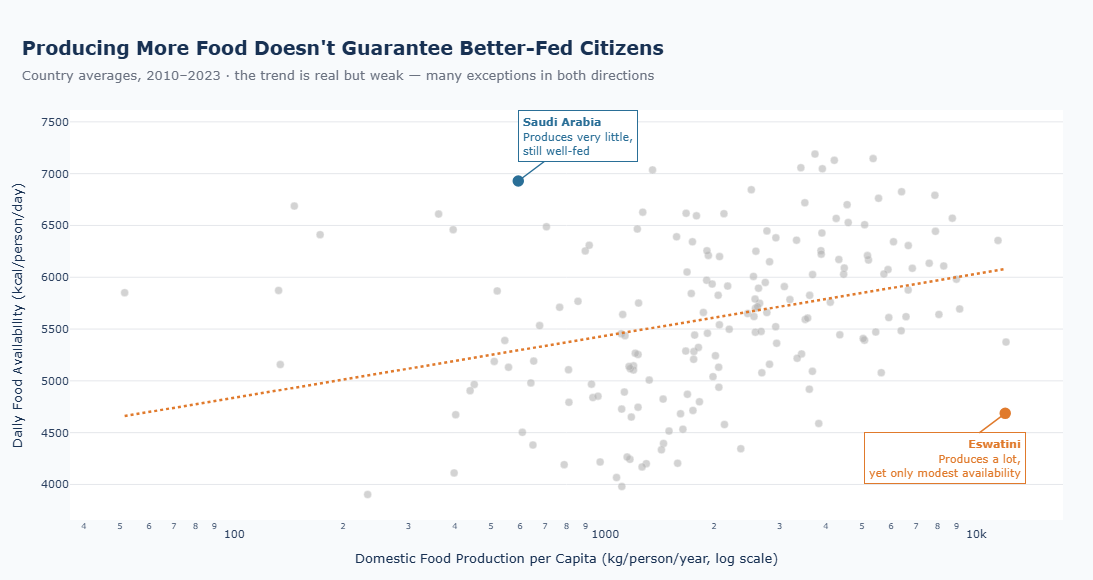

In [57]:
# ==========================================================
# AQ7 - Domestic Production vs Food Availability
# ==========================================================

import plotly.express as px
import plotly.graph_objects as go
import numpy as np

fig = px.scatter(
    aq7_country, x="Production_per_Capita_kg", y="Calories_per_Capita",
    trendline="ols", trendline_options=dict(log_x=True),
    log_x=True, hover_name="Country",
    labels={"Production_per_Capita_kg": "Domestic Food Production per Capita (kg/person/year, log scale)",
            "Calories_per_Capita": "Daily Food Availability (kcal/person/day)"}
)

# base cloud = grey context
fig.update_traces(marker=dict(size=8, color=CONTEXT_GREY, opacity=0.55,
                               line=dict(color="white", width=0.4)),
                   selector=dict(mode="markers"))
fig.update_traces(line=dict(color=HIGHLIGHT, width=2.5, dash="dot"), selector=dict(mode="lines"))

# --- highlighted points now carry the SAME colour as their annotation ---
fig.add_trace(go.Scatter(
    x=[example_low_prod_high_cal["Production_per_Capita_kg"]],
    y=[example_low_prod_high_cal["Calories_per_Capita"]],
    mode="markers",
    marker=dict(size=13, color=BASE_BLUE, line=dict(color="white", width=1.5)),
    hovertext=[example_low_prod_high_cal["Country"]], hoverinfo="text", showlegend=False
))

fig.add_trace(go.Scatter(
    x=[example_high_prod_low_cal["Production_per_Capita_kg"]],
    y=[example_high_prod_low_cal["Calories_per_Capita"]],
    mode="markers",
    marker=dict(size=13, color=HIGHLIGHT, line=dict(color="white", width=1.5)),
    hovertext=[example_high_prod_low_cal["Country"]], hoverinfo="text", showlegend=False
))

# --- annotations, colour-matched to their point ---
fig.add_annotation(
    x=np.log10(example_low_prod_high_cal["Production_per_Capita_kg"]),
    y=example_low_prod_high_cal["Calories_per_Capita"],
    xref="x", yref="y",
    text=f"<b>{example_low_prod_high_cal['Country']}</b><br>Produces very little,<br>still well-fed",
    showarrow=True, arrowcolor=BASE_BLUE, arrowwidth=1.5, ax=60, ay=-45,
    font=dict(size=11, color=BASE_BLUE), align="left",
    bgcolor="white", bordercolor=BASE_BLUE, borderwidth=1, borderpad=4
)

fig.add_annotation(
    x=np.log10(example_high_prod_low_cal["Production_per_Capita_kg"]),
    y=example_high_prod_low_cal["Calories_per_Capita"],
    xref="x", yref="y",
    text=f"<b>{example_high_prod_low_cal['Country']}</b><br>Produces a lot,<br>yet only modest availability",
    showarrow=True, arrowcolor=HIGHLIGHT, arrowwidth=1.5, ax=-60, ay=45,
    font=dict(size=11, color=HIGHLIGHT), align="right",
    bgcolor="white", bordercolor=HIGHLIGHT, borderwidth=1, borderpad=4
)

fig.update_layout(
    template="plotly_white", height=580,
    paper_bgcolor=BG, plot_bgcolor="white", showlegend=False,
    title=dict(
        text="<b>Producing More Food Doesn't Guarantee Better-Fed Citizens</b>"
             "<br><span style='font-size:13px;color:#6B7280'>Country averages, 2010–2023 · the trend is real but weak — many exceptions in both directions</span>",
        x=0.02, font=dict(size=19, color=COLOR_NAVY)
    ),
    xaxis=dict(title="Domestic Food Production per Capita (kg/person/year, log scale)",
               title_font=dict(size=13, color=COLOR_NAVY), tickfont=dict(size=11),
               showgrid=False, zeroline=False),
    yaxis=dict(title="Daily Food Availability (kcal/person/day)", title_font=dict(size=13, color=COLOR_NAVY),
               tickfont=dict(size=11), gridcolor=COLOR_GRID, zeroline=False),
    margin=dict(l=70, r=30, t=110, b=60)
)

fig.show(config={"displayModeBar": False})

### Key Insight

The relationship between domestic production and food availability is real but weak, with meaningful exceptions in both directions — some countries produce very little yet remain well-fed through trade and income, while others produce a great deal yet achieve only modest availability, likely due to distribution or export patterns.

**Business Insight**

Boosting domestic production alone is not a guaranteed food-security fix; policy should pair production incentives with distribution, storage, and market-access improvements to ensure output actually reaches the population.

---

## Analytical Question 8

### Does more agricultural land automatically improve food security?

It's tempting to assume that a larger farming footprint directly translates into more food for a population. This analysis tests that assumption directly, rather than taking it for granted, by comparing food availability across countries grouped by their share of agricultural land.

**Goal:** Compare median daily calorie availability across agricultural land categories to determine whether agricultural land share alone is a reliable predictor of national food security.

In [58]:
# ==========================================================
# AQ8
# Data Preparation
# ==========================================================

import pandas as pd
import numpy as np

aq8_df = (
    analysis_df
    .query("Item == 'Grand Total'")
    .dropna(subset=[
        "Agricultural_Land_Percent",
        "Calories_per_Capita",
        "GDP_per_Capita"
    ])
    .copy()
)

In [59]:
# ==========================================================
# AQ8
# Create Agricultural Land Categories
# ==========================================================

aq8_df["Land_Category"] = pd.cut(
    aq8_df["Agricultural_Land_Percent"],
    bins=[0, 20, 40, 60, 80, 100],
    labels=[
        "Very Low",
        "Low",
        "Moderate",
        "High",
        "Very High"
    ],
    include_lowest=True
)

# ==========================================================
# Create Executive Summary Table
# ==========================================================

aq8_summary = (
    aq8_df
    .groupby("Land_Category", observed=True)
    .agg(
        Median_Calories=("Calories_per_Capita", "median"),
        Median_GDP=("GDP_per_Capita", "median"),
        Countries=("Country", "nunique")
    )
    .reset_index()
)

# Round values for presentation
aq8_summary["Median_Calories"] = aq8_summary["Median_Calories"].round(0)
aq8_summary["Median_GDP"] = aq8_summary["Median_GDP"].round(0)

# Labels displayed above each bar
aq8_summary["Calories_Label"] = (
    aq8_summary["Median_Calories"]
    .map(lambda x: f"{x:,.0f} kcal")
)

display(aq8_summary)

,Land_Category,Median_Calories,Median_GDP,Countries,Calories_Label
0,Very Low,2961.0,9635.0,47,"2,961 kcal"
1,Low,2848.0,6205.0,53,"2,848 kcal"
2,Moderate,3101.0,6249.0,61,"3,101 kcal"
3,High,2679.0,2787.0,31,"2,679 kcal"
4,Very High,3033.0,12534.0,7,"3,033 kcal"


In [60]:
# ==========================================================
# AQ8
# Executive Visualization
# ==========================================================

import plotly.express as px

CONTEXT_BLUE = "#D7E8F5"
HIGHLIGHT_BLUE = "#2F6690"

bar_colors = [
    CONTEXT_BLUE,     # Very Low
    CONTEXT_BLUE,     # Low
    HIGHLIGHT_BLUE,   # Moderate (highlight)
    CONTEXT_BLUE,     # High
    CONTEXT_BLUE      # Very High
]

fig = px.bar(
    aq8_summary,
    x="Land_Category",
    y="Median_Calories",
    text="Calories_Label"
)

fig.update_traces(
    marker_color=bar_colors,
    marker_line_color="white",
    marker_line_width=1.5,
    textposition="outside",
    cliponaxis=False,
    customdata=aq8_summary[["Median_GDP", "Countries"]],
    hovertemplate=
        "<b>%{x}</b><br><br>"
        "Median Calories: %{y:,.0f} kcal/day"
        "<br>"
        "Median GDP: US$%{customdata[0]:,.0f}"
        "<br>"
        "Countries: %{customdata[1]}"
        "<extra></extra>"
)

fig.update_layout(
    template="plotly_white",
    width=1100,
    height=650,
    paper_bgcolor=BG,         
    plot_bgcolor="white",     
    showlegend=False,
    margin=dict(l=90, r=60, t=120, b=80),
    font=dict(family="Arial", color="#374151", size=12),

    title=dict(
        text="<b>Agricultural Land Share Alone Does Not Predict Food Security</b>"
             "<br><span style='font-size:14px;color:#6B7280'>"
             "Median daily calorie availability across agricultural land categories.</span>",
        x=0.02, y=0.97, xanchor="left",
        font=dict(size=22, color=COLOR_NAVY)   
    ),

    xaxis=dict(
        title="Agricultural Land Share",
        title_font=dict(size=15, color=COLOR_NAVY),
        tickfont=dict(size=12),
        showgrid=False, zeroline=False
    ),

    yaxis=dict(
        title="Median Daily Food Availability (kcal/person/day)",
        title_font=dict(size=15, color=COLOR_NAVY),
        tickfont=dict(size=11),
        showgrid=True, gridcolor=COLOR_GRID, zeroline=False,
        range=[0, aq8_summary["Median_Calories"].max() * 1.15]
    )
)

fig.show(config={"displayModeBar": False})


In [61]:
# ==========================================================
# AQ8
# Statistical Validation
# ==========================================================

from scipy.stats import spearmanr

aq8_corr_df = (
    analysis_df
    .query("Item == \'Grand Total\'")
    .dropna(
        subset=[
            "Agricultural_Land_Percent",
            "Calories_per_Capita"
        ]
    )
    .groupby("Country", as_index=False)
    .agg({
        "Agricultural_Land_Percent": "mean",
        "Calories_per_Capita": "mean"
    })
)

rho, p_value = spearmanr(
    aq8_corr_df["Agricultural_Land_Percent"],
    aq8_corr_df["Calories_per_Capita"]
)

print("=" * 60)
print("AQ8 Statistical Validation (country-level averages)")
print("=" * 60)
print(f"Spearman Correlation : {rho:.3f}")
print(f"P-value              : {p_value:.4f}")
print("=" * 60)

AQ8 Statistical Validation (country-level averages)
Spearman Correlation : -0.036
P-value              : 0.6386


### Key Insight

A larger share of agricultural land does not automatically translate into greater food availability. Countries with moderate agricultural land often achieve calorie availability comparable to — or higher than — countries with very high agricultural land shares, and the weak Spearman correlation reinforces that land share alone is not a strong predictor of food security.

**Business Insight**

Development strategies should not rely on agricultural land expansion as a primary food-security lever; investment in productivity, technology, infrastructure, and trade access is likely to deliver a larger return than simply farming more land.

---

## Analytical Question 9

### Has economic growth kept pace with improvements in food availability since 2010?

Having established a cross-sectional link between GDP and food availability (AQ1), this question tests whether that relationship holds up as a trend — whether rising incomes over time have translated into proportional gains in food security.

**Goal:** Compare the trajectory of average GDP per capita against average daily calorie availability across all countries between 2010 and 2023, indexed to a common baseline so the two growth rates are directly comparable.

In [62]:
# ==========================================================
# AQ9 - Economic Growth vs Food Availability Over Time
# ==========================================================

aq9_df = (
    analysis_df
    .query("Item == 'Grand Total'")
    .dropna(
        subset=[
            "GDP_per_Capita",
            "Calories_per_Capita"
        ]
    )
)

aq9_plot = (
    aq9_df
    .groupby("Year", as_index=False)
    .agg(
        Average_GDP=(
            "GDP_per_Capita",
            "mean"
        ),
        Average_Calories=(
            "Calories_per_Capita",
            "mean"
        )
    )
)

aq9_plot["GDP_Index"] = (
    aq9_plot["Average_GDP"] / aq9_plot["Average_GDP"].iloc[0] * 100
)
aq9_plot["Calorie_Index"] = (
    aq9_plot["Average_Calories"] / aq9_plot["Average_Calories"].iloc[0] * 100
)

display(aq9_plot.head())

,Year,Average_GDP,Average_Calories,GDP_Index,Calorie_Index
0,2010,12998.159196,2853.190357,100.000000,100.000000
1,2011,14387.403393,2864.991726,110.688007,100.413620
2,2012,14271.173330,2871.256250,109.793803,100.633182
3,2013,14787.102750,2879.890238,113.763053,100.935790
4,2014,14948.326086,2886.067679,115.003408,101.152300


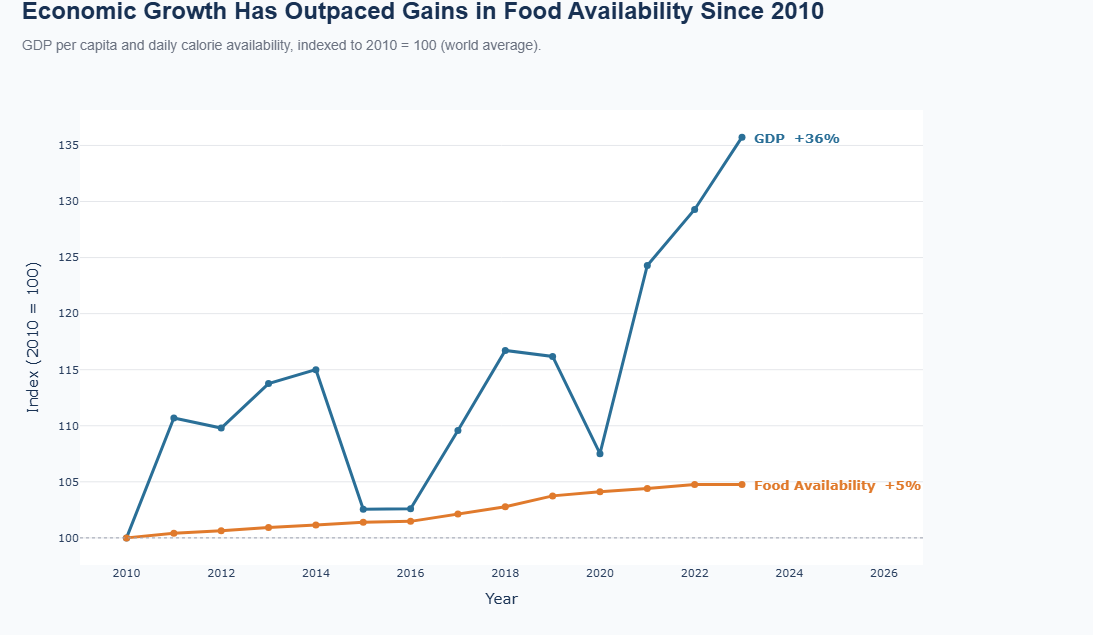

In [63]:
# ==========================================================
# AQ9 - Executive Trend Chart (indexed, single axis)
# ==========================================================

import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=aq9_plot["Year"],
        y=aq9_plot["GDP_Index"],
        mode="lines+markers",
        name="GDP per Capita (Index)",
        line=dict(color=BASE_BLUE, width=3),
        marker=dict(size=7, color=BASE_BLUE),
        hovertemplate="<b>Year</b>: %{x}<br><b>GDP Index</b>: %{y:.0f}<extra></extra>"
    )
)

fig.add_trace(
    go.Scatter(
        x=aq9_plot["Year"],
        y=aq9_plot["Calorie_Index"],
        mode="lines+markers",
        name="Food Availability (Index)",
        line=dict(color=HIGHLIGHT, width=3),
        marker=dict(size=7, color=HIGHLIGHT),
        hovertemplate="<b>Year</b>: %{x}<br><b>Calorie Index</b>: %{y:.0f}<extra></extra>"
    )
)

# Direct end-of-line labels instead of a legend box - both series
# share one axis so labelling the lines directly is the clearer read.
fig.add_annotation(
    x=aq9_plot["Year"].iloc[-1], y=aq9_plot["GDP_Index"].iloc[-1],
    text=f"<b>GDP  +{aq9_plot['GDP_Index'].iloc[-1]-100:.0f}%</b>",
    showarrow=False, xanchor="left", xshift=10,
    font=dict(size=13, color=BASE_BLUE)
)
fig.add_annotation(
    x=aq9_plot["Year"].iloc[-1], y=aq9_plot["Calorie_Index"].iloc[-1],
    text=f"<b>Food Availability  +{aq9_plot['Calorie_Index'].iloc[-1]-100:.0f}%</b>",
    showarrow=False, xanchor="left", xshift=10,
    font=dict(size=13, color=HIGHLIGHT)
)

fig.add_hline(y=100, line_color="#9CA3AF", line_dash="dot", line_width=1)

fig.update_layout(
    template="plotly_white",
    width=1100,
    height=620,
    paper_bgcolor=BG,
    plot_bgcolor="white",
    showlegend=False,
    margin=dict(l=80, r=170, t=110, b=70),
    title=dict(
        text="<b>Economic Growth Has Outpaced Gains in Food Availability Since 2010</b>"
             "<br><span style='font-size:14px;color:#6B7280'>"
             "GDP per capita and daily calorie availability, indexed to 2010 = 100 (world average).</span>",
        x=0.02, y=0.97, xanchor="left",
        font=dict(family="Arial", size=24, color=COLOR_NAVY)
    )
)

fig.update_xaxes(
    title_text="Year", showgrid=False, tickfont=dict(size=11),
    title_font=dict(size=15, color=COLOR_NAVY)
)
fig.update_yaxes(
    title_text="Index (2010 = 100)", showgrid=True, gridcolor=COLOR_GRID,
    title_font=dict(size=15, color=COLOR_NAVY), tickfont=dict(size=11)
)

fig.show(config={"displayModeBar": False})

In [64]:
# ==========================================================
# AQ9 - Trend Statistics
# ==========================================================

import numpy as np

# ----------------------------------------------------------
# Overall Growth (2010 → 2023)
# ----------------------------------------------------------

gdp_growth = (
    (aq9_plot.iloc[-1]["Average_GDP"] -
     aq9_plot.iloc[0]["Average_GDP"])
    /
    aq9_plot.iloc[0]["Average_GDP"]
) * 100

calorie_growth = (
    (aq9_plot.iloc[-1]["Average_Calories"] -
     aq9_plot.iloc[0]["Average_Calories"])
    /
    aq9_plot.iloc[0]["Average_Calories"]
) * 100

# ----------------------------------------------------------
# Correlation
# ----------------------------------------------------------

corr = aq9_plot["Average_GDP"].corr(
    aq9_plot["Average_Calories"]
)

print("="*70)
print("AQ9 - TREND SUMMARY")
print("="*70)

print(f"GDP Growth (2010–2023)           : {gdp_growth:.2f}%")
print(f"Calorie Growth (2010–2023)       : {calorie_growth:.2f}%")
print(f"GDP vs Calories Correlation      : {corr:.3f}")

# ----------------------------------------------------------
# Annual Change Table
# ----------------------------------------------------------

aq9_summary = aq9_plot.copy()

aq9_summary["GDP Growth %"] = (
    aq9_summary["Average_GDP"]
    .pct_change()*100
)

aq9_summary["Calories Growth %"] = (
    aq9_summary["Average_Calories"]
    .pct_change()*100
)

display(
    aq9_summary.round(2)
)

AQ9 - TREND SUMMARY
GDP Growth (2010–2023)           : 35.74%
Calorie Growth (2010–2023)       : 4.77%
GDP vs Calories Correlation      : 0.744


,Year,Average_GDP,Average_Calories,GDP_Index,Calorie_Index,GDP Growth %,Calories Growth %
0,2010,12998.16,2853.19,100.00,100.00,NaN,NaN
1,2011,14387.40,2864.99,110.69,100.41,10.69,0.41
2,2012,14271.17,2871.26,109.79,100.63,-0.81,0.22
3,2013,14787.10,2879.89,113.76,100.94,3.62,0.30
4,2014,14948.33,2886.07,115.00,101.15,1.09,0.21
5,2015,13329.27,2892.68,102.55,101.38,-10.83,0.23
6,2016,13334.92,2895.21,102.59,101.47,0.04,0.09
7,2017,14242.29,2914.14,109.57,102.14,6.80,0.65
8,2018,15170.58,2932.35,116.71,102.77,6.52,0.62
9,2019,15101.24,2960.06,116.18,103.75,-0.46,0.94


### Key Insight

Average GDP per capita increased steadily over the period, and calorie availability improved too, but at a considerably slower rate. The gap between income growth and food-availability growth points to diminishing returns — additional income increasingly fails to translate into proportional food-security gains.

**Business Insight**

Sustained progress on food security will depend more on targeted investment in agricultural productivity, food distribution systems, and climate resilience than on continued income growth alone.

---

## Analytical Question 10

### Which countries achieved the greatest improvement in food availability since 2010?

Aggregate global trends (AQ9, AQ11) can mask which specific countries are driving progress and which are being left behind. Ranking countries by their own improvement identifies concrete success stories worth studying.

**Goal:** Identify the countries with the largest increase in daily calorie availability between 2010 and 2023.

In [65]:
# ==========================================================
# AQ10 - Improvement in Food Availability
# ==========================================================

aq10_df = (
    analysis_df
    .query("Item == 'Grand Total'")
    .dropna(subset=["Calories_per_Capita"])
)

# ----------------------------------------------------------
# First and Last Available Year
# ----------------------------------------------------------

start_year = aq10_df["Year"].min()
end_year = aq10_df["Year"].max()

start_df = (
    aq10_df[aq10_df["Year"] == start_year]
    [["Country", "Calories_per_Capita"]]
    .rename(columns={
        "Calories_per_Capita": "Calories_2010"
    })
)

end_df = (
    aq10_df[aq10_df["Year"] == end_year]
    [["Country", "Calories_per_Capita"]]
    .rename(columns={
        "Calories_per_Capita": "Calories_2023"
    })
)

aq10_plot = (
    start_df
    .merge(
        end_df,
        on="Country",
        how="inner"
    )
)

aq10_plot["Improvement"] = (
    aq10_plot["Calories_2023"] -
    aq10_plot["Calories_2010"]
)

aq10_plot = (
    aq10_plot
    .sort_values(
        "Improvement",
        ascending=False
    )
)

display(aq10_plot.head())


,Country,Calories_2010,Calories_2023,Improvement
41,Dominican Republic,2590.88,3313.44,722.56
62,Guyana,2603.20,3318.06,714.86
97,Mongolia,2438.71,3031.07,592.36
118,Philippines,2411.14,2982.90,571.76
133,Serbia,3330.89,3878.93,548.04


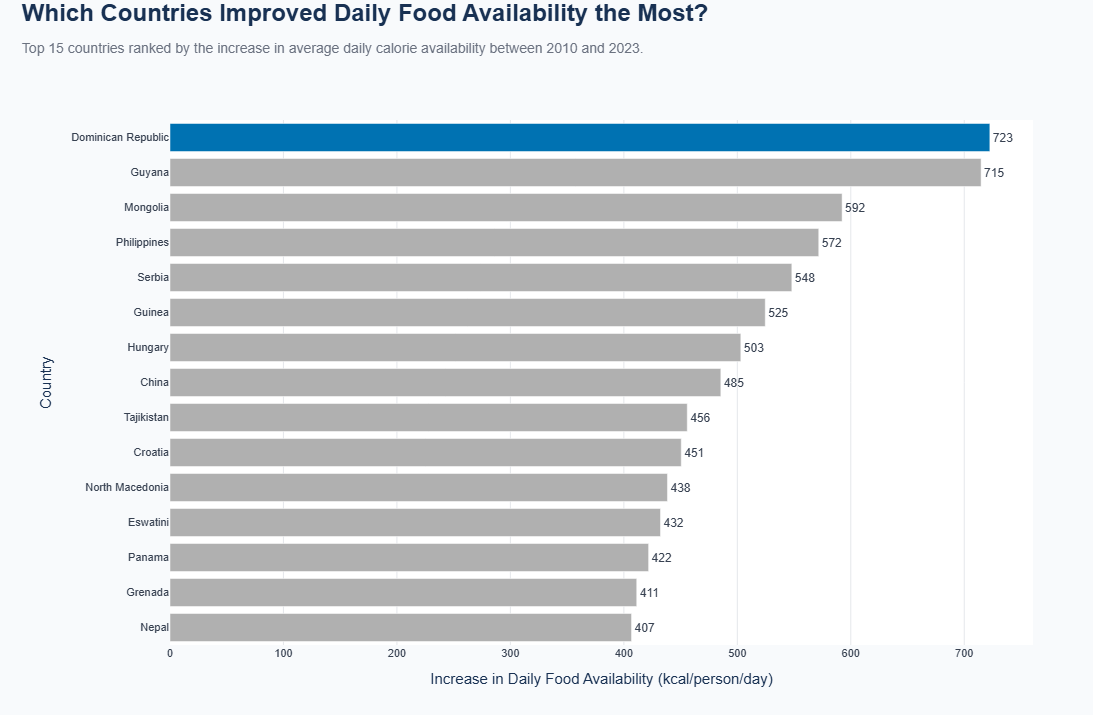

In [66]:
# ==========================================================
# AQ10 - Countries with the Largest Improvement
# ==========================================================

import plotly.express as px

# ----------------------------------------------------------
# Top 15 Countries
# ----------------------------------------------------------
top15 = (
    aq10_plot
    .head(15)
    .sort_values("Improvement")
)

# Flat context colour for all bars, highlight reserved for the
# single largest improver - avoids a colour gradient that repeats
# information already carried by bar length with no colour legend.
bar_colors = [CONTEXT_GREY] * (len(top15) - 1) + [HIGHLIGHT_ALT]  # distinct from AQ5's HIGHLIGHT

fig = px.bar(
    top15,
    x="Improvement",
    y="Country",
    orientation="h",
    text="Improvement"
)

# ----------------------------------------------------------
# Labels
# ----------------------------------------------------------
fig.update_traces(
    marker_color=bar_colors,
    texttemplate="%{text:.0f}",
    textposition="outside",
    hovertemplate=
    "<b>%{y}</b><br>" +
    "Increase: %{x:.0f} kcal/person/day<extra></extra>"
)

# ----------------------------------------------------------
# Layout
# ----------------------------------------------------------
fig.update_layout(
    template="plotly_white",
    width=1100,
    height=700,
    paper_bgcolor=BG,
    plot_bgcolor="white",
    showlegend=False,
    margin=dict(
        l=170,
        r=60,
        t=120,
        b=70
    ),
    title=dict(
        text="<b>Which Countries Improved Daily Food Availability the Most?</b>"
             "<br>"
             "<span style='font-size:14px;color:#6B7280'>"
             "Top 15 countries ranked by the increase in average daily calorie availability between 2010 and 2023."
             "</span>",
        x=0.02,
        y=0.97,
        xanchor="left",
        font=dict(
            family="Arial",
            size=24,
            color=COLOR_NAVY
        )
    ),

    xaxis=dict(
        title="Increase in Daily Food Availability (kcal/person/day)",
        title_font=dict(
            size=15,
            color=COLOR_NAVY
        ),
        tickfont=dict(size=11),
        showgrid=True,
        gridcolor=COLOR_GRID,
        zeroline=False
    ),

    yaxis=dict(
        title="Country",
        title_font=dict(
            size=15,
            color=COLOR_NAVY
        ),
        tickfont=dict(size=11)
    ),
    font=dict(
        family="Arial",
        color="#374151"
    )

)

fig.show(config={"displayModeBar": False})

In [67]:
# ==========================================================
# AQ10 - Summary Statistics
# ==========================================================

print("=" * 70)
print("AQ10 - SUMMARY STATISTICS")
print("=" * 70)

# ----------------------------------------------------------
# Overall Statistics
# ----------------------------------------------------------

mean_change = aq10_plot["Improvement"].mean()

median_change = aq10_plot["Improvement"].median()

max_change = aq10_plot["Improvement"].max()

min_change = aq10_plot["Improvement"].min()

print(f"Average Improvement : {mean_change:.2f} kcal/person/day")
print(f"Median Improvement  : {median_change:.2f} kcal/person/day")
print(f"Largest Improvement : {max_change:.2f} kcal/person/day")
print(f"Largest Decline     : {min_change:.2f} kcal/person/day")

# ----------------------------------------------------------
# Top 10 Countries
# ----------------------------------------------------------

print("\nTop 10 Improvements")
display(
    aq10_plot.head(10).round(2)
)

# ----------------------------------------------------------
# Bottom 10 Countries
# ----------------------------------------------------------

print("\nLargest Declines")
display(
    aq10_plot.tail(10).round(2)
)

# ----------------------------------------------------------
# Distribution Statistics
# ----------------------------------------------------------

print("\nDistribution")

display(
    aq10_plot["Improvement"]
    .describe()
    .round(2)
)



AQ10 - SUMMARY STATISTICS
Average Improvement : 123.80 kcal/person/day
Median Improvement  : 135.51 kcal/person/day
Largest Improvement : 722.56 kcal/person/day
Largest Decline     : -829.89 kcal/person/day

Top 10 Improvements


,Country,Calories_2010,Calories_2023,Improvement
41,Dominican Republic,2590.88,3313.44,722.56
62,Guyana,2603.20,3318.06,714.86
97,Mongolia,2438.71,3031.07,592.36
118,Philippines,2411.14,2982.90,571.76
133,Serbia,3330.89,3878.93,548.04
60,Guinea,2422.92,2947.55,524.63
65,Hungary,3046.03,3549.11,503.08
29,China,3041.44,3526.90,485.46
146,Tajikistan,2255.80,2711.69,455.89
34,Croatia,2996.99,3447.57,450.58



Largest Declines


,Country,Calories_2010,Calories_2023,Improvement
138,Solomon Islands,2416.18,2165.63,-250.55
53,"Gambia, The",2676.13,2402.32,-273.81
164,"Yemen, Rep.",2096.55,1810.53,-286.02
27,"Hong Kong SAR, China",3126.61,2827.73,-298.88
112,Oman,3283.36,2981.33,-302.03
154,Ukraine,3097.05,2785.79,-311.26
79,Kuwait,3548.12,3135.58,-412.54
155,United Arab Emirates,3659.24,3125.09,-534.15
84,Lesotho,2530.77,1872.70,-658.07
145,Syrian Arab Republic,3089.25,2259.36,-829.89



Distribution


count    167.00
mean     123.80
std      231.07
min     -829.89
25%       -8.91
50%      135.51
75%      265.59
max      722.56
Name: Improvement, dtype: float64

### Key Insight

Improvement in food availability was highly uneven: a handful of countries achieved substantial gains, while others saw only marginal improvement or outright decline. This spread suggests factors beyond economic growth — agricultural policy, infrastructure, trade integration, and climate resilience — meaningfully shape outcomes.

**Business Insight**

Benchmarking the top-improving countries can surface scalable, exportable strategies that donor organizations and policymakers can adapt for countries currently facing stagnation.

---

## Analytical Question 11

### How have global food supply and climate patterns evolved from 2010 to 2023?

Individual relationships tested elsewhere (AQ1, AQ2) are cross-sectional snapshots. This question steps back to ask whether the world as a whole has been gaining or losing ground on food security as climate pressure has intensified.

**Goal:** Track global average food availability alongside global average temperature change across the study period, indexed to a common baseline, to assess whether supply gains have kept pace with climate pressure.

In [68]:
# ==========================================================
# AQ11 - Global Trends (2010–2023)
# ==========================================================

aq11_df = (
    national_df
    .groupby("Year", as_index=False)
    .agg(
        Avg_Calories=("Calories_per_Capita", "mean"),
        Avg_Temperature=("Temperature_Change", "mean"),
        Avg_GDP=("GDP_per_Capita", "mean"),
        Countries=("Country", "nunique")
    )
)

aq11_df = aq11_df.sort_values("Year")

# Index both series to a common 2010 = 100 baseline, consistent
# with AQ9, so calorie and temperature trajectories are directly
# comparable on a single axis rather than a dual-axis chart.
aq11_df["Calorie_Index"] = (
    aq11_df["Avg_Calories"] / aq11_df["Avg_Calories"].iloc[0] * 100
)
aq11_df["Temperature_Index"] = (
    aq11_df["Avg_Temperature"] / aq11_df["Avg_Temperature"].iloc[0] * 100
)

display(aq11_df.head())

,Year,Avg_Calories,Avg_Temperature,Avg_GDP,Countries,Calorie_Index,Temperature_Index
0,2010,5481.557219,1.105285,12998.159196,169,100.000000,100.000000
1,2011,5500.577337,0.785527,14387.403393,169,100.346984,71.070120
2,2012,5512.192604,0.904994,14271.173330,169,100.558881,81.878797
3,2013,5526.530473,0.927361,14787.102750,169,100.820447,83.902484
4,2014,5534.200651,1.129934,14948.326086,169,100.960374,102.230094


In [69]:
# ==========================================================
# Summary Statistics
# ==========================================================

calorie_change = (
    aq11_df["Avg_Calories"].iloc[-1]
    - aq11_df["Avg_Calories"].iloc[0]
)

temperature_change = (
    aq11_df["Avg_Temperature"].iloc[-1]
    - aq11_df["Avg_Temperature"].iloc[0]
)

print(f"Average calorie change : {calorie_change:.1f} kcal")
print(f"Average temperature change : {temperature_change:.2f} °C")

Average calorie change : 234.4 kcal
Average temperature change : 0.58 °C


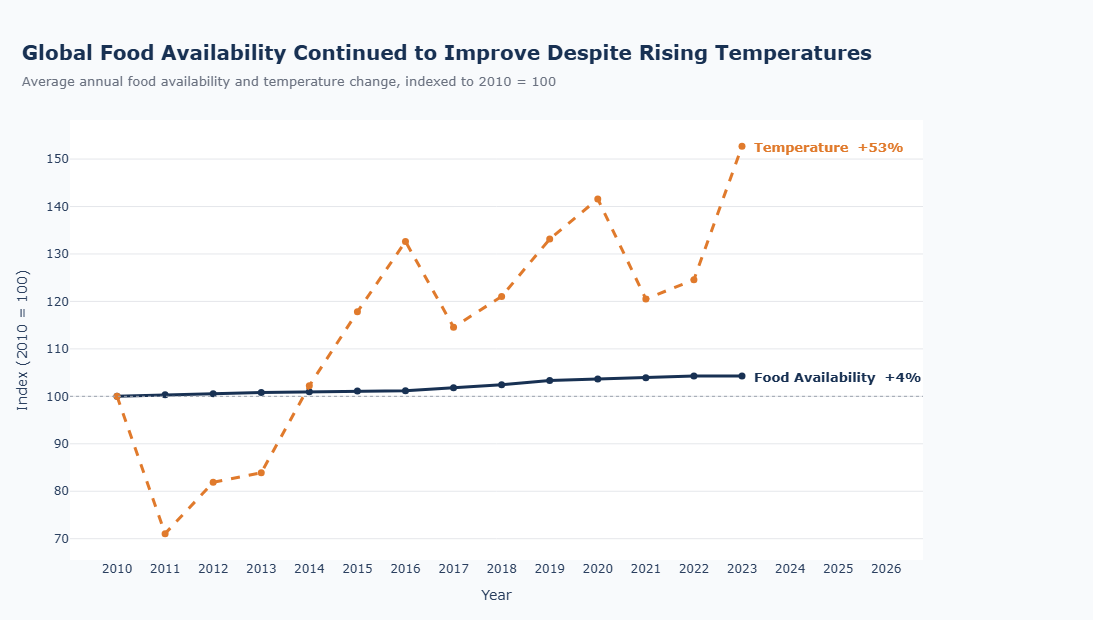

In [70]:
# ==========================================================
# AQ11 - Executive Trend Dashboard (indexed, single axis)
# ==========================================================

import plotly.graph_objects as go

fig = go.Figure()

# ----------------------------------------------------------
# Food Availability
# ----------------------------------------------------------
fig.add_trace(
    go.Scatter(
        x=aq11_df["Year"],
        y=aq11_df["Calorie_Index"],
        mode="lines+markers",
        name="Food Availability (Index)",
        line=dict(color=COLOR_NAVY, width=3),
        marker=dict(size=7, color=COLOR_NAVY),
        hovertemplate="<b>%{x}</b><br>Calorie Index: %{y:.0f}<extra></extra>"
    )
)

# ----------------------------------------------------------
# Temperature
# ----------------------------------------------------------
fig.add_trace(
    go.Scatter(
        x=aq11_df["Year"],
        y=aq11_df["Temperature_Index"],
        mode="lines+markers",
        name="Temperature Change (Index)",
        line=dict(color=HIGHLIGHT, width=3, dash="dash"),
        marker=dict(size=7, color=HIGHLIGHT),
        hovertemplate="<b>%{x}</b><br>Temperature Index: %{y:.0f}<extra></extra>"
    )
)

# ----------------------------------------------------------
# Direct end-of-line labels (no legend needed - two series, one axis)
# ----------------------------------------------------------
fig.add_annotation(
    x=aq11_df["Year"].iloc[-1], y=aq11_df["Calorie_Index"].iloc[-1],
    text=f"<b>Food Availability  +{aq11_df['Calorie_Index'].iloc[-1]-100:.0f}%</b>",
    showarrow=False, xanchor="left", xshift=10,
    font=dict(size=13, color=COLOR_NAVY)
)
fig.add_annotation(
    x=aq11_df["Year"].iloc[-1], y=aq11_df["Temperature_Index"].iloc[-1],
    text=f"<b>Temperature  +{aq11_df['Temperature_Index'].iloc[-1]-100:.0f}%</b>",
    showarrow=False, xanchor="left", xshift=10,
    font=dict(size=13, color=HIGHLIGHT)
)

fig.add_hline(y=100, line_color="#9CA3AF", line_dash="dot", line_width=1)

# ----------------------------------------------------------
# Layout
# ----------------------------------------------------------
fig.update_layout(
    template="plotly_white",
    paper_bgcolor=BG,
    plot_bgcolor="white",
    height=620,
    showlegend=False,
    hovermode="x unified",
    title=dict(
        text="<b>Global Food Availability Continued to Improve Despite Rising Temperatures</b>"
             "<br><span style='font-size:13px;color:#6B7280'>Average annual food availability and temperature change, indexed to 2010 = 100</span>",
        x=0.02,
        font=dict(size=20, color=COLOR_NAVY)
    ),
    margin=dict(l=70, r=170, t=120, b=60)
)

fig.update_xaxes(title="Year", showgrid=False, tickmode="linear")
fig.update_yaxes(title_text="Index (2010 = 100)", gridcolor=COLOR_GRID, zeroline=False)

fig.show(config={
    "displayModeBar": False,
    "displaylogo": False
})

In [71]:
# ==========================================================
# AQ11 - Executive Insight
# ==========================================================

from IPython.display import Markdown, display

avg_growth = (
    (aq11_df["Avg_Calories"].iloc[-1] /
     aq11_df["Avg_Calories"].iloc[0] - 1) * 100
)

temp_growth = (
    (aq11_df["Avg_Temperature"].iloc[-1] -
     aq11_df["Avg_Temperature"].iloc[0])
)

display(Markdown(f"""
### Key Insight

Between **2010 and 2023**, global food availability increased by **{calorie_change:.0f} kcal/person/day**
(**{avg_growth:.1f}%**), while the average global temperature anomaly increased by
**{temp_growth:.2f}°C**.

Although climate pressures continued to intensify throughout the study period,
global food availability followed a generally upward trajectory.
This suggests that improvements in agricultural productivity,
international food trade and technological advancement helped offset
part of the adverse effects associated with climate change.

**Business Insight**

Global-level optimism should not drive country-level complacency — the aggregate trend masks countries that are falling behind, which is precisely why a country-level resilience view (**AQ12**) is needed to guide targeted intervention.
"""))


### Key Insight

Between **2010 and 2023**, global food availability increased by **234 kcal/person/day**
(**4.3%**), while the average global temperature anomaly increased by
**0.58°C**.

Although climate pressures continued to intensify throughout the study period,
global food availability followed a generally upward trajectory.
This suggests that improvements in agricultural productivity,
international food trade and technological advancement helped offset
part of the adverse effects associated with climate change.

**Business Insight**

Global-level optimism should not drive country-level complacency — the aggregate trend masks countries that are falling behind, which is precisely why a country-level resilience view (**AQ12**) is needed to guide targeted intervention.


---

## Analytical Question 12

### Which countries represent the best and worst overall balance of climate resilience and food security?

No single indicator — GDP, temperature, or trade dependence alone — fully captures a country's food-security position. This closing analysis combines multiple dimensions into one composite view to identify which countries are managing the full set of pressures well, and which are not.

**Goal:** Build a composite resilience index from food availability, GDP per capita, temperature change, and import dependency, and rank countries by their overall performance. Each component is min-max normalized to a 0–1 scale and equally weighted, so no single dimension dominates the index.

In [72]:
# ==========================================================
# AQ12 - Climate Resilience & Food Security Index
# ==========================================================

from sklearn.preprocessing import MinMaxScaler

aq12_df = national_df.copy()

# ----------------------------------------------------------
# Import Dependency
# ----------------------------------------------------------

aq12_df["Import_Dependency"] = (
    aq12_df["Imports"]
    .div(aq12_df["Domestic_Supply"])
    .mul(100)
    .clip(lower=0, upper=100)
)

# ----------------------------------------------------------
# Country Average
# ----------------------------------------------------------

aq12_country = (

    aq12_df

    .groupby("Country",as_index=False)

    .agg(

        Calories=("Calories_per_Capita","mean"),

        GDP=("GDP_per_Capita","mean"),

        Temperature=("Temperature_Change","mean"),

        Import_Dependency=("Import_Dependency","mean")

    )

)

display(aq12_country.head())

,Country,Calories,GDP,Temperature,Import_Dependency
0,Afghanistan,4380.712143,522.874223,1.204214,32.642541
1,Albania,5894.537143,5615.795731,1.576214,23.950375
2,Algeria,6465.777143,4991.592930,1.559714,42.633076
3,Angola,4870.555000,3630.432766,0.964286,12.887932
4,Antigua and Barbuda,4673.012857,16960.037181,0.794714,86.482459


In [73]:
# ==========================================================
# Normalisation
# ==========================================================

scaler = MinMaxScaler()

aq12_country["Calories_Score"] = scaler.fit_transform(
    aq12_country[["Calories"]]
)

aq12_country["GDP_Score"] = scaler.fit_transform(
    aq12_country[["GDP"]]
)

aq12_country["Temperature_Score"] = 1 - scaler.fit_transform(
    aq12_country[["Temperature"]]
)

aq12_country["Import_Score"] = 1 - scaler.fit_transform(
    aq12_country[["Import_Dependency"]]
)

In [74]:
# ==========================================================
# Composite Index
# ==========================================================

aq12_country["Resilience_Index"] = (

    aq12_country[

        [

            "Calories_Score",

            "GDP_Score",

            "Temperature_Score",

            "Import_Score"

        ]

    ]

    .mean(axis=1)

)

aq12_country = aq12_country.sort_values(

    "Resilience_Index",

    ascending=False

)

display(aq12_country.head())

,Country,Calories,GDP,Temperature,Import_Dependency,Calories_Score,GDP_Score,Temperature_Score,Import_Score,Resilience_Index
168,United States,7145.055000,60787.947777,1.150571,14.878411,0.986580,0.514669,0.568752,0.862753,0.733189
7,Australia,6570.174286,59389.724803,0.959143,12.234358,0.811641,0.502736,0.678084,0.889552,0.720503
5,Argentina,6108.810714,12230.676419,0.695214,3.626360,0.671246,0.100237,0.828823,0.976799,0.644276
73,Ireland,7047.089286,73271.843710,0.937714,71.834202,0.956768,0.621219,0.690323,0.285475,0.638446
115,New Zealand,6135.645000,42702.311913,0.799929,26.724035,0.679412,0.360310,0.769017,0.742691,0.637857


In [75]:
# ==========================================================
# AQ12 - Select Best and Worst Performing Countries
# ==========================================================

TOP_N = 10

top_countries = (
    aq12_country
    .nlargest(TOP_N, "Resilience_Index")
    .sort_values("Resilience_Index")
)

bottom_countries = (
    aq12_country
    .nsmallest(TOP_N, "Resilience_Index")
    .sort_values("Resilience_Index")
)

display(top_countries)
display(bottom_countries)

,Country,Calories,GDP,Temperature,Import_Dependency,Calories_Score,GDP_Score,Temperature_Score,Import_Score,Resilience_Index
80,Kiribati,6074.353571,1840.441626,0.834500,14.571560,0.660760,0.011557,0.749272,0.865863,0.571863
21,Brazil,6355.372857,10210.332499,1.267857,1.818733,0.746276,0.082994,0.501766,0.995120,0.581539
29,China,6380.375000,9067.235037,NaN,9.278732,0.753884,0.073237,NaN,0.919509,0.582210
28,Chile,5749.428571,14749.183946,0.395500,33.093800,0.561884,0.121732,1.000000,0.678130,0.590437
37,Cuba,6528.334000,7441.544445,0.958700,14.664828,0.798909,0.059362,0.678337,0.864918,0.600381
115,New Zealand,6135.645000,42702.311913,0.799929,26.724035,0.679412,0.360310,0.769017,0.742691,0.637857
73,Ireland,7047.089286,73271.843710,0.937714,71.834202,0.956768,0.621219,0.690323,0.285475,0.638446
5,Argentina,6108.810714,12230.676419,0.695214,3.626360,0.671246,0.100237,0.828823,0.976799,0.644276
7,Australia,6570.174286,59389.724803,0.959143,12.234358,0.811641,0.502736,0.678084,0.889552,0.720503
168,United States,7145.055000,60787.947777,1.150571,14.878411,0.986580,0.514669,0.568752,0.862753,0.733189


,Country,Calories,GDP,Temperature,Import_Dependency,Calories_Score,GDP_Score,Temperature_Score,Import_Score,Resilience_Index
174,"Yemen, Rep.",3902.975000,1130.914376,NaN,67.175332,0.000000,0.005502,NaN,3.326956e-01,0.112732
54,"Gambia, The",4905.362143,713.864680,1.435929,68.780086,0.305031,0.001942,4.057750e-01,3.164306e-01,0.257295
72,Iraq,5187.792143,5436.911634,1.805071,58.525912,0.390976,0.042253,1.949446e-01,4.203621e-01,0.262134
100,Mauritania,5533.457143,1797.353234,1.616500,75.728250,0.496163,0.011190,3.026444e-01,2.460072e-01,0.264001
142,Slovenia,6050.059286,25051.338411,1.933357,92.959221,0.653368,0.209660,1.216762e-01,7.136207e-02,0.264017
11,Bahrain,6687.200000,27702.209411,2.146400,100.000000,0.847252,0.232285,1.110223e-16,1.110223e-16,0.269884
41,Djibouti,5157.299286,2404.032614,0.936462,100.000000,0.381697,0.016367,6.910380e-01,1.110223e-16,0.272276
86,Latvia,6088.809286,16049.161552,1.883000,83.422938,0.665159,0.132828,1.504369e-01,1.680174e-01,0.279110
77,Jordan,5190.509286,4125.124580,1.414571,72.698234,0.391803,0.031057,4.179728e-01,2.767181e-01,0.279388
88,Lesotho,4111.602143,1093.575931,0.935714,59.646656,0.063486,0.005183,6.914648e-01,4.090028e-01,0.292284


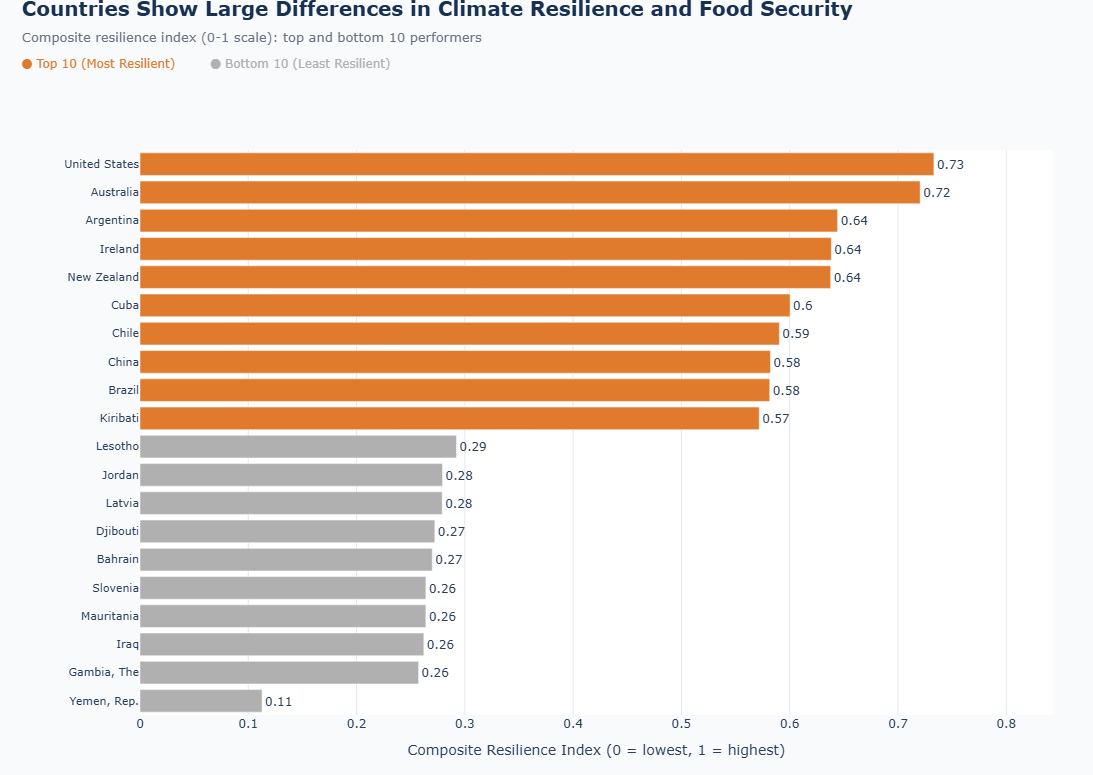

In [76]:
# ==========================================================
# AQ12 - Top & Bottom Performers 
# ==========================================================

import plotly.graph_objects as go
import pandas as pd

top = (
    aq12_country
    .nlargest(10, "Resilience_Index")
    .sort_values("Resilience_Index")
)

bottom = (
    aq12_country
    .nsmallest(10, "Resilience_Index")
    .sort_values("Resilience_Index")
)

plot_df = pd.concat([bottom, top], ignore_index=True)

fig = go.Figure()

fig.add_trace(
    go.Bar(
        y=bottom["Country"],
        x=bottom["Resilience_Index"],
        orientation="h",
        marker_color=CONTEXT_GREY,
        text=bottom["Resilience_Index"].round(2),
        textposition="outside",
        showlegend=False,
        hovertemplate="<b>%{y}</b><br>Index: %{x:.2f}<extra></extra>"
    )
)

fig.add_trace(
    go.Bar(
        y=top["Country"],
        x=top["Resilience_Index"],
        orientation="h",
        marker_color=HIGHLIGHT,
        text=top["Resilience_Index"].round(2),
        textposition="outside",
        showlegend=False,
        hovertemplate="<b>%{y}</b><br>Index: %{x:.2f}<extra></extra>"
    )
)

fig.update_layout(
    template="plotly_white",
    width=1100,
    paper_bgcolor=BG,
    plot_bgcolor="white",
    height=760,
    barmode="overlay",
    showlegend=False,

    title=dict(
        text="<b>Countries Show Large Differences in Climate Resilience and Food Security</b>"
             "<br><span style='font-size:13px;color:#6B7280'>Composite resilience index (0-1 scale): top and bottom 10 performers</span>"
             "<br><span style='font-size:12px;color:" + HIGHLIGHT + "'>⬤ Top 10 (Most Resilient)</span>"
             "&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;"
             "<span style='font-size:12px;color:" + CONTEXT_GREY + "'>⬤ Bottom 10 (Least Resilient)</span>",
        x=0.02, y=0.98, yanchor="top",
        font=dict(size=20, color=COLOR_NAVY)
    ),

    xaxis=dict(
        title="Composite Resilience Index (0 = lowest, 1 = highest)",
        range=[0, plot_df["Resilience_Index"].max() * 1.15],
        showgrid=True, gridcolor=COLOR_GRID, zeroline=False
    ),

    yaxis=dict(
        title="",
        categoryorder="array",
        categoryarray=plot_df.sort_values("Resilience_Index")["Country"],
        tickfont=dict(size=11)
    ),

    margin=dict(l=140, r=40, t=150, b=60)   
)

fig.show(config={"displayModeBar": False, "displaylogo": False})

### Key Insight

Countries at the top of the index combine strong food availability with economic resilience and comparatively low import dependency, even under climate stress — while countries at the bottom show compounding vulnerabilities across multiple dimensions simultaneously, not just a single weak indicator.

**Business Insight**

Countries clustered at the bottom of the index are the highest-priority candidates for coordinated, multi-dimensional support (economic, agricultural, and trade) rather than single-lever aid, since their vulnerability is structural rather than driven by one fixable factor.